# ProtT5 Tissue Enrichment MLP

Multi-label tissue-enrichment classifier using **ProtT5 protein language model embeddings** (1024-dim, max-pool + attention-pool).

## Pipeline
1. Load TISSUES gene-attribute matrix (235 valid tissues)
2. Load pre-computed ProtT5 pooled embeddings from NFS
3. Train shared-backbone MLP for all 235 tissues (multi-label)
4. Evaluate macro ROC-AUC / PR-AUC per tissue and across pools
5. Focused 5-label classifier: Brain / Testis / Lung / Liver / Kidney
6. Publication-grade plots saved to `prodt5_results/`

In [1]:
# ============================================================
# IMPORTS & GLOBAL PLOT SETTINGS
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# ── Publication-grade aesthetics ────────────────────────────
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi":         150,
    "savefig.dpi":        300,
    "font.family":        "sans-serif",
    "axes.titlesize":     13,
    "axes.labelsize":     12,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "legend.framealpha":  0.85,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})

PALETTE = sns.color_palette("tab10")
SEED    = 42
np.random.seed(SEED)

OUT_DIR = "prodt5_results"
os.makedirs(OUT_DIR, exist_ok=True)
print("Output directory:", os.path.abspath(OUT_DIR))

Output directory: /home/saishyam/Protein_dynamics/Dynamic_properties/Protein_Cell_tissue_confidence/prodt5_results


In [2]:
# ============================================================
# LOAD DATA & ASSIGN REAL TISSUE COLUMN NAMES
# ============================================================

# --- Tissue names from original matrix (row 0, cols 3+) ---
raw_meta = pd.read_csv(
    "gene_attribute_matrix.txt",
    sep="\t", header=None, nrows=1, low_memory=False
)
tissue_names_raw = raw_meta.iloc[0, 3:].tolist()

# --- Load mapped CSV ---
df = pd.read_csv("TISSUES_with_UniProt_mapped.csv", low_memory=False)
print("Loaded shape:", df.shape)

tissue_cols_orig = df.columns[3:-1].tolist()
n_tissue_cols  = len(tissue_cols_orig)
n_tissue_names = len(tissue_names_raw)

seen, deduped_names = {}, []
for name in tissue_names_raw:
    if name not in seen:
        seen[name] = 0
        deduped_names.append(str(name))
    else:
        seen[name] += 1
        deduped_names.append(f"{name}_{seen[name]}")

if n_tissue_cols > n_tissue_names:
    extra = [f"tissue_extra_{i}" for i in range(n_tissue_cols - n_tissue_names)]
    deduped_names = deduped_names + extra
else:
    deduped_names = deduped_names[:n_tissue_cols]

rename_map = dict(zip(tissue_cols_orig, deduped_names))
df = df.rename(columns=rename_map)
TISSUE_COLS = deduped_names

print(f"Tissue columns : {len(TISSUE_COLS)}")
print("First 5:", TISSUE_COLS[:5])
df[["GeneSym", "ENSP", "UniProt_ID"] + TISSUE_COLS[:3]].head()

Loaded shape: (13705, 250)
Tissue columns : 246
First 5: ['fetus', 'placenta', 'embryonic structure', 'organism form', 'internal female genital organ']


,GeneSym,ENSP,UniProt_ID,fetus,placenta,embryonic structure
0,ZNF627,ENSP00000354414,Q7L945,0.0,0.0,0.0
1,ZNF544,ENSP00000269829,Q6NX49,0.0,0.0,0.0
2,ZNF540,ENSP00000324598,Q8NDQ6,0.0,0.0,0.0
3,ZNF512,ENSP00000347648,Q96ME7,0.0,0.0,0.0
4,ADAT1,ENSP00000310015,Q9BUB4,0.0,0.0,0.0


Tissues ≥10 positives: 235 / 246
Positive fraction — mean: 0.0722  min: 0.0010  max: 0.9987


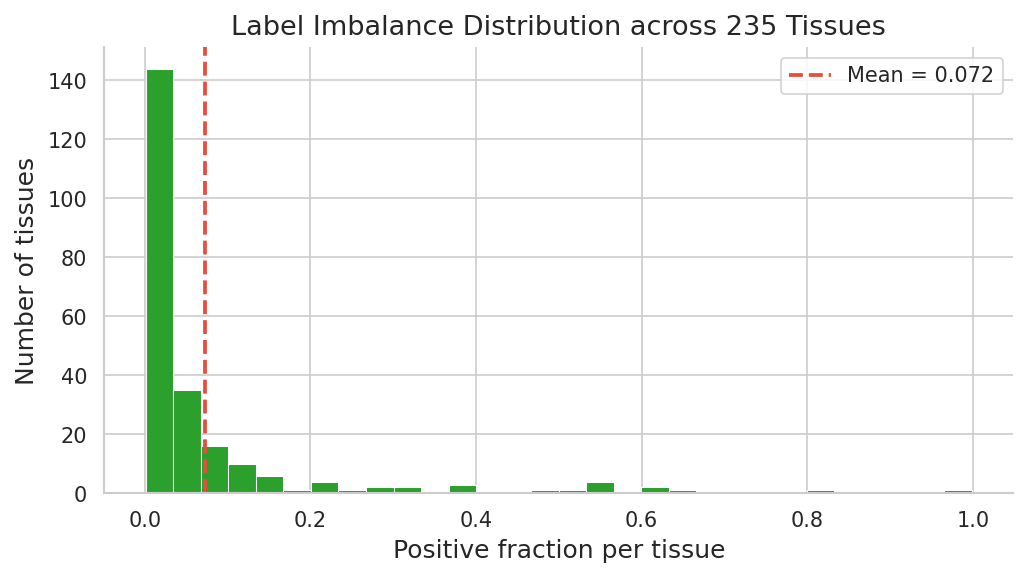

In [3]:
# ============================================================
# LABEL MATRIX — filter out tissues with < 10 positive examples
# ============================================================

label_df = df[TISSUE_COLS].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.float32)
pos_counts   = (label_df == 1).sum()
valid_tissues = pos_counts[(pos_counts >= 10) & (pos_counts < len(df))].index.tolist()

print(f"Tissues ≥10 positives: {len(valid_tissues)} / {len(TISSUE_COLS)}")

label_df    = label_df[valid_tissues]
TISSUE_COLS = valid_tissues
pos_frac    = (label_df == 1).mean()

print(f"Positive fraction — mean: {pos_frac.mean():.4f}  "
      f"min: {pos_frac.min():.4f}  max: {pos_frac.max():.4f}")

# ── Publication plot: label imbalance distribution ──────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pos_frac, bins=30, color=PALETTE[2], edgecolor="white", linewidth=0.5)
ax.axvline(pos_frac.mean(), color="#e74c3c", lw=1.8, ls="--",
           label=f"Mean = {pos_frac.mean():.3f}")
ax.set_xlabel("Positive fraction per tissue")
ax.set_ylabel("Number of tissues")
ax.set_title("Label Imbalance Distribution across 235 Tissues")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "label_distribution.png"), bbox_inches="tight")
plt.show()

In [4]:
# ============================================================
# LOAD PRE-COMPUTED ProtT5 EMBEDDINGS  (1024-dim, NFS)
# ============================================================

EMBED_FILE = Path("/nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref") \
             / "protT5_embedding_cache" / "pooled_embeddings.npz"

print(f"Embedding file : {EMBED_FILE}")
print(f"Exists         : {EMBED_FILE.exists()}")

cache     = np.load(EMBED_FILE, allow_pickle=True)
max_pool  = cache["max"].item()    # dict: UniProt_ID → (1024,)
attn_pool = cache["attn"].item()   # dict: UniProt_ID → (1024,)

emb_dim = next(iter(max_pool.values())).shape[0]
print(f"Proteins in cache (max) : {len(max_pool):,}")
print(f"Proteins in cache (attn): {len(attn_pool):,}")
print(f"Embedding dim           : {emb_dim}")

our_ids = df["UniProt_ID"].dropna().unique().tolist()
covered = [uid for uid in our_ids if uid in max_pool]
print(f"\nOur proteins          : {len(our_ids):,}")
print(f"Covered by cache (max): {len(covered):,}  "
      f"({100*len(covered)/len(our_ids):.1f}%)")

Embedding file : /nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/protT5_embedding_cache/pooled_embeddings.npz
Exists         : True
Proteins in cache (max) : 18,459
Proteins in cache (attn): 18,459
Embedding dim           : 1024

Our proteins          : 13,692
Covered by cache (max): 13,081  (95.5%)


In [5]:
# ============================================================
# BUILD X (embeddings) AND Y (labels) FOR BOTH POOL TYPES
# ============================================================

from sklearn.model_selection import train_test_split

def collect_embeddings(df_in, pool_dict, label=""):
    """Stack embeddings; skip proteins missing from cache."""
    vecs, missing = [], []
    for uid in df_in["UniProt_ID"]:
        vec = pool_dict.get(uid)
        if vec is None:
            missing.append(uid)
        else:
            vecs.append(vec)
    if missing:
        print(f"[{label}] Missing embeddings: {len(missing)}")
    return np.stack(vecs).astype(np.float32)

df_ml = df[df["UniProt_ID"].isin(max_pool)].reset_index(drop=True)
print(f"Proteins with embeddings: {len(df_ml):,}")

X_max  = collect_embeddings(df_ml, max_pool,  "max")
X_attn = collect_embeddings(df_ml, attn_pool, "attn")
Y      = df_ml[TISSUE_COLS].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.float32).values

print(f"X_max  : {X_max.shape}")
print(f"X_attn : {X_attn.shape}")
print(f"Y      : {Y.shape}")

idx = np.arange(len(df_ml))
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=SEED)
splits = {
    "max":  (X_max[idx_train],  X_max[idx_test]),
    "attn": (X_attn[idx_train], X_attn[idx_test]),
}
Y_train, Y_test = Y[idx_train], Y[idx_test]
print(f"\nTrain: {len(idx_train):,}  |  Test: {len(idx_test):,}")
print(f"Tissues (labels): {Y.shape[1]}")

Proteins with embeddings: 13,093
X_max  : (13093, 1024)
X_attn : (13093, 1024)
Y      : (13093, 235)

Train: 10,474  |  Test: 2,619
Tissues (labels): 235


In [6]:
# ============================================================
# DEDUPLICATION — remove duplicate UniProt IDs
# ============================================================

n_before = len(df_ml)
dup_mask = df_ml["UniProt_ID"].duplicated(keep="first")
n_dups   = dup_mask.sum()

print(f"Proteins before dedup : {n_before:,}")
print(f"Duplicate UniProt IDs : {n_dups}")

if n_dups > 0:
    dup_ids = df_ml.loc[dup_mask, "UniProt_ID"].value_counts().head(5)
    print("\nExample duplicates:")
    print(dup_ids.to_string())

    df_ml  = df_ml[~dup_mask].reset_index(drop=True)
    X_max  = collect_embeddings(df_ml, max_pool,  "max")
    X_attn = collect_embeddings(df_ml, attn_pool, "attn")
    Y      = df_ml[TISSUE_COLS].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.float32).values

    idx = np.arange(len(df_ml))
    idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=SEED)
    splits = {
        "max":  (X_max[idx_train],  X_max[idx_test]),
        "attn": (X_attn[idx_train], X_attn[idx_test]),
    }
    Y_train, Y_test = Y[idx_train], Y[idx_test]
    print(f"\nProteins after dedup  : {len(df_ml):,}")
    print(f"Train: {len(idx_train):,}  |  Test: {len(idx_test):,}")
else:
    print("No duplicates found — data is clean.")

Proteins before dedup : 13,093
Duplicate UniProt IDs : 12

Example duplicates:
UniProt_ID
Q96JG8    1
P0DN86    1
P69905    1
P84243    1
Q02325    1

Proteins after dedup  : 13,081
Train: 10,464  |  Test: 2,617


In [7]:
# ============================================================
# MLP MODEL — shared backbone + multi-label output head
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


class TissueEnrichmentMLP(nn.Module):
    """Shared backbone → per-tissue binary heads (1024-dim ProtT5 input)."""
    def __init__(self, input_dim: int, num_tissues: int):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.head = nn.Linear(256, num_tissues)

    def forward(self, x):
        return self.head(self.backbone(x))


pos_counts_tr  = Y_train.sum(axis=0)
neg_counts_tr  = len(Y_train) - pos_counts_tr
pos_weights    = np.where(pos_counts_tr > 0, neg_counts_tr / pos_counts_tr, 1.0)
pos_weights    = np.clip(pos_weights, 1.0, 50.0).astype(np.float32)
pos_weight_tensor = torch.from_numpy(pos_weights).to(device)

print(f"pos_weight — min: {pos_weights.min():.2f}  max: {pos_weights.max():.2f}  "
      f"mean: {pos_weights.mean():.2f}")
print(f"Input dim  : {emb_dim}")
print(f"Output dim : {Y_train.shape[1]} tissues")

Device: cuda
pos_weight — min: 1.00  max: 50.00  mean: 34.65
Input dim  : 1024
Output dim : 235 tissues



  Training with MAX pooling


/nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/protT5_env/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


  Epoch 010/40 | Loss: 0.4148
  Epoch 020/40 | Loss: 0.2830
  Epoch 030/40 | Loss: 0.2152
  Epoch 040/40 | Loss: 0.1979

  Training with ATTN pooling
  Epoch 010/40 | Loss: 0.4961
  Epoch 020/40 | Loss: 0.3878
  Epoch 030/40 | Loss: 0.3134
  Epoch 040/40 | Loss: 0.2919


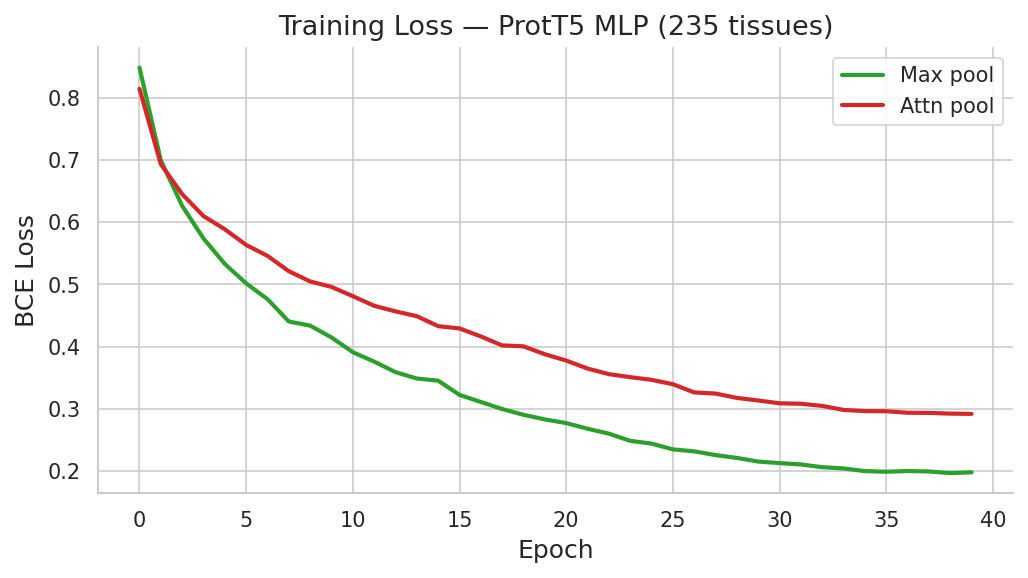

In [8]:
# ============================================================
# TRAINING — one MLP per pooling strategy (235-label)
# ============================================================

from sklearn.metrics import roc_auc_score, average_precision_score

EPOCHS     = 40
BATCH_SIZE = 64
LR         = 1e-3

trained_models    = {}
train_loss_curves = {}

for pool_name, (X_tr, X_te) in splits.items():
    print(f"\n{'='*52}")
    print(f"  Training with {pool_name.upper()} pooling")
    print(f"{'='*52}")

    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(Y_train))
    test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(Y_test))
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    model     = TissueEnrichmentMLP(X_tr.shape[1], Y_train.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    losses = []
    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:03d}/{EPOCHS} | Loss: {avg_loss:.4f}")

    trained_models[pool_name]    = (model, test_loader)
    train_loss_curves[pool_name] = losses

# ── Publication plot: training loss ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_loss_curves["max"],  lw=2, color=PALETTE[2], label="Max pool")
ax.plot(train_loss_curves["attn"], lw=2, color=PALETTE[3], label="Attn pool")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.set_title("Training Loss — ProtT5 MLP (235 tissues)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_loss_235.png"), bbox_inches="tight")
plt.show()

[MAX  pool]  tissues: 235
  Macro ROC-AUC : 0.7688 ± 0.0765
  Macro PR-AUC  : 0.2771 ± 0.1709
[ATTN pool]  tissues: 235
  Macro ROC-AUC : 0.7968 ± 0.0709
  Macro PR-AUC  : 0.3383 ± 0.1705


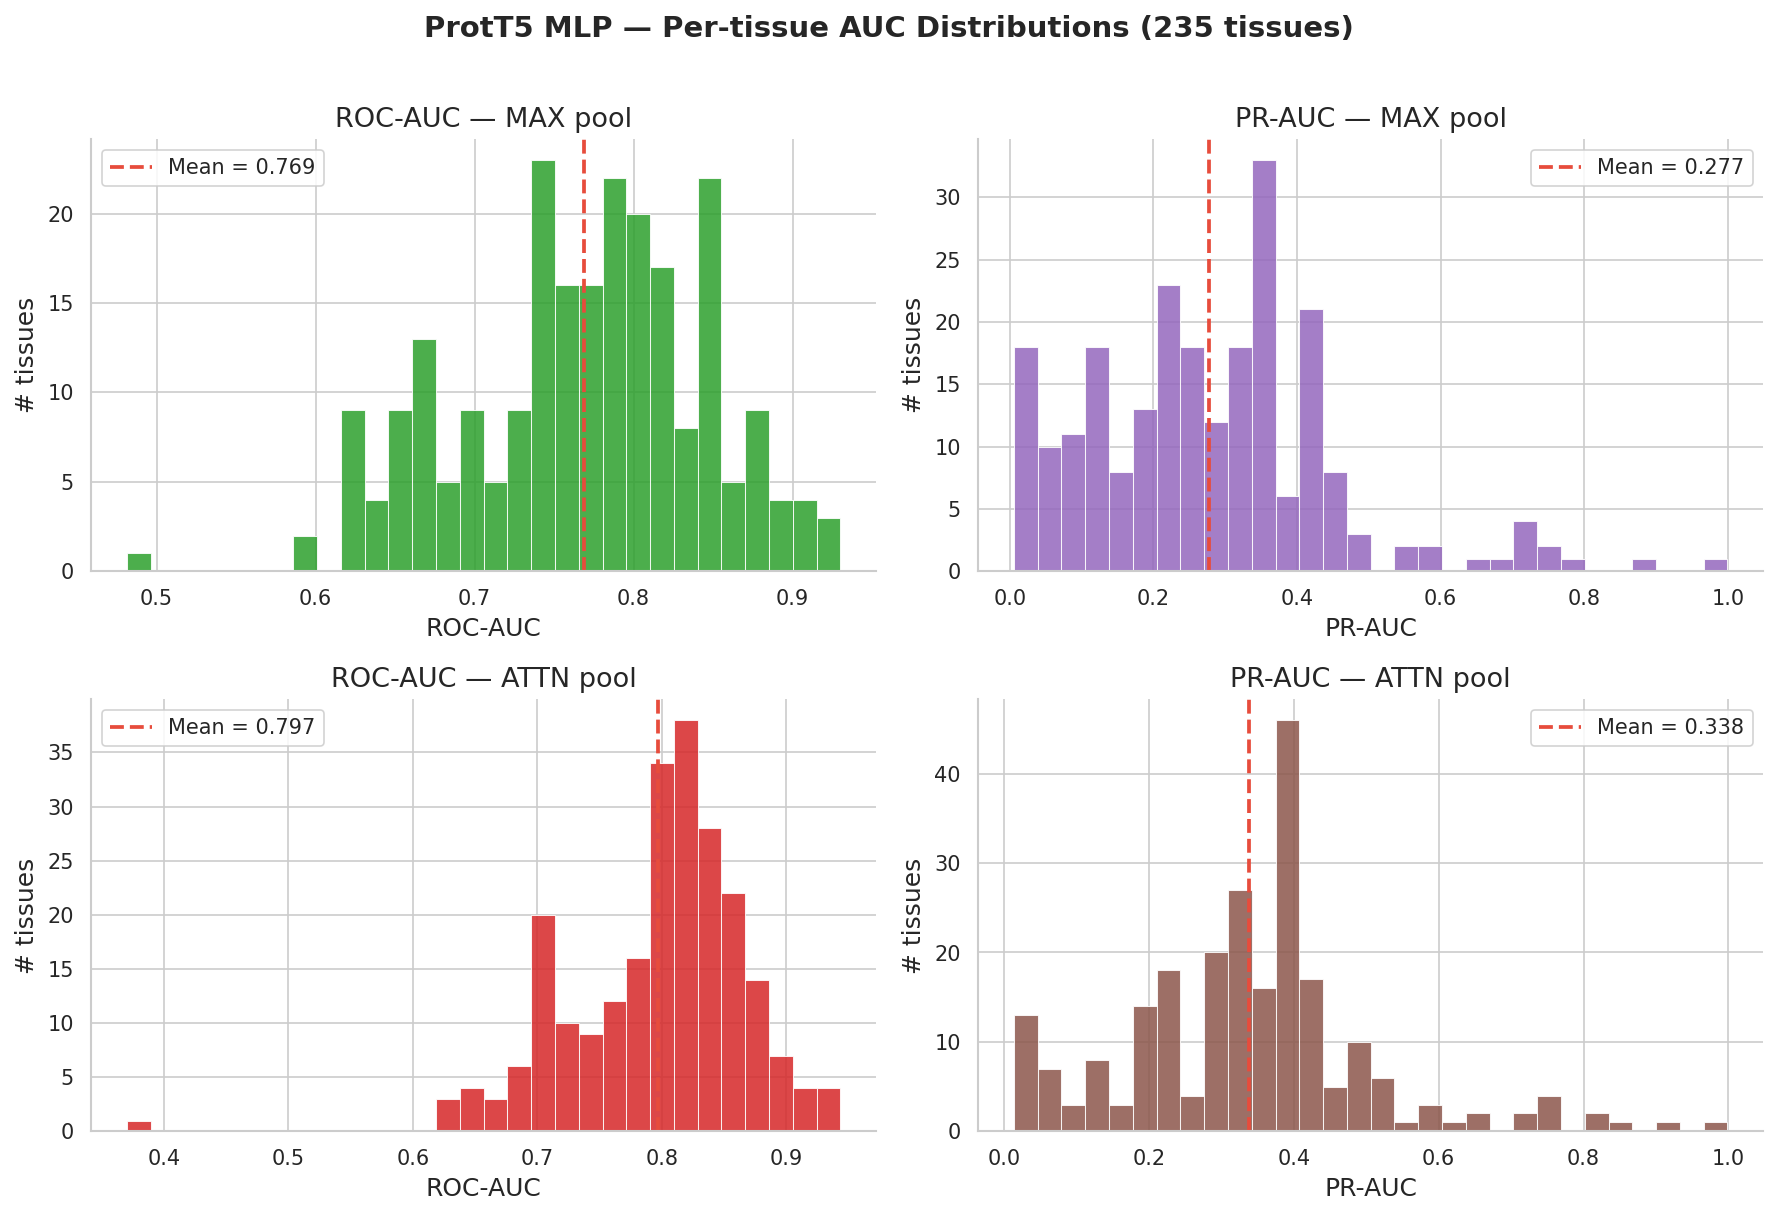

In [9]:
# ============================================================
# EVALUATION — per-tissue ROC-AUC and PR-AUC (both pools)
# ============================================================

eval_results = {}

for pool_name, (model, test_loader) in trained_models.items():
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb.to(device)).cpu().numpy()
            all_logits.append(logits)
            all_labels.append(yb.numpy())

    Y_pred_logits = np.concatenate(all_logits)
    Y_true        = np.concatenate(all_labels)
    Y_prob        = 1 / (1 + np.exp(-Y_pred_logits))

    roc_aucs, pr_aucs, tnames = [], [], []
    for i, tname in enumerate(TISSUE_COLS):
        yt = Y_true[:, i]
        yp = Y_prob[:, i]
        if yt.sum() == 0 or yt.sum() == len(yt):
            continue
        roc_aucs.append(roc_auc_score(yt, yp))
        pr_aucs.append(average_precision_score(yt, yp))
        tnames.append(tname)

    roc_aucs = np.array(roc_aucs)
    pr_aucs  = np.array(pr_aucs)
    eval_results[pool_name] = dict(
        roc_aucs=roc_aucs, pr_aucs=pr_aucs,
        tissue_names=tnames, Y_true=Y_true, Y_prob=Y_prob
    )
    print(f"[{pool_name.upper():4s} pool]  tissues: {len(roc_aucs)}")
    print(f"  Macro ROC-AUC : {roc_aucs.mean():.4f} ± {roc_aucs.std():.4f}")
    print(f"  Macro PR-AUC  : {pr_aucs.mean():.4f} ± {pr_aucs.std():.4f}")

# ── Publication plot: AUC distributions ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (pool_name, res) in enumerate(eval_results.items()):
    for col, (metric, values, color) in enumerate([
        ("ROC-AUC", res["roc_aucs"], PALETTE[row + 2]),
        ("PR-AUC",  res["pr_aucs"],  PALETTE[row + 4]),
    ]):
        ax = axes[row, col]
        ax.hist(values, bins=30, color=color, edgecolor="white", linewidth=0.5, alpha=0.85)
        ax.axvline(values.mean(), color="#e74c3c", lw=1.8, ls="--",
                   label=f"Mean = {values.mean():.3f}")
        ax.set_title(f"{metric} — {pool_name.upper()} pool")
        ax.set_xlabel(metric); ax.set_ylabel("# tissues")
        ax.legend()

plt.suptitle("ProtT5 MLP — Per-tissue AUC Distributions (235 tissues)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "per_tissue_auc_distributions.png"), bbox_inches="tight")
plt.show()


  MAX pool — Top 10 tissues by ROC-AUC


,tissue,roc_auc,pr_auc,pos_count_test
147,adrenal cortex,0.930044,0.456463,9
110,pancreatic islet,0.919542,0.402926,20
109,endocrine pancreas,0.917982,0.402413,20
105,respiratory epithelium,0.903155,0.342164,32
104,bronchial epithelium,0.902382,0.342692,32
103,epithelium,0.902200,0.342223,32
106,bronchial epithelial cell,0.902067,0.341778,32
113,cytotoxic t-lymphocyte,0.899862,0.446685,19
212,smooth muscle,0.894257,0.023285,5
111,t-lymphocyte,0.889954,0.460299,25



  ATTN pool — Top 10 tissues by ROC-AUC


,tissue,roc_auc,pr_auc,pos_count_test
98,vascular system,0.943501,0.352504,38
226,culture condition:cd4+ cell,0.937019,0.114161,16
113,cytotoxic t-lymphocyte,0.934687,0.497985,19
217,gut,0.926269,0.295640,27
220,b-lymphocyte,0.911880,0.118919,28
99,bone,0.909019,0.394888,43
112,helper t-lymphocyte,0.907917,0.499631,25
111,t-lymphocyte,0.907253,0.498582,25
46,cardiac muscle,0.896711,0.398715,84
102,lymph,0.895862,0.300985,37


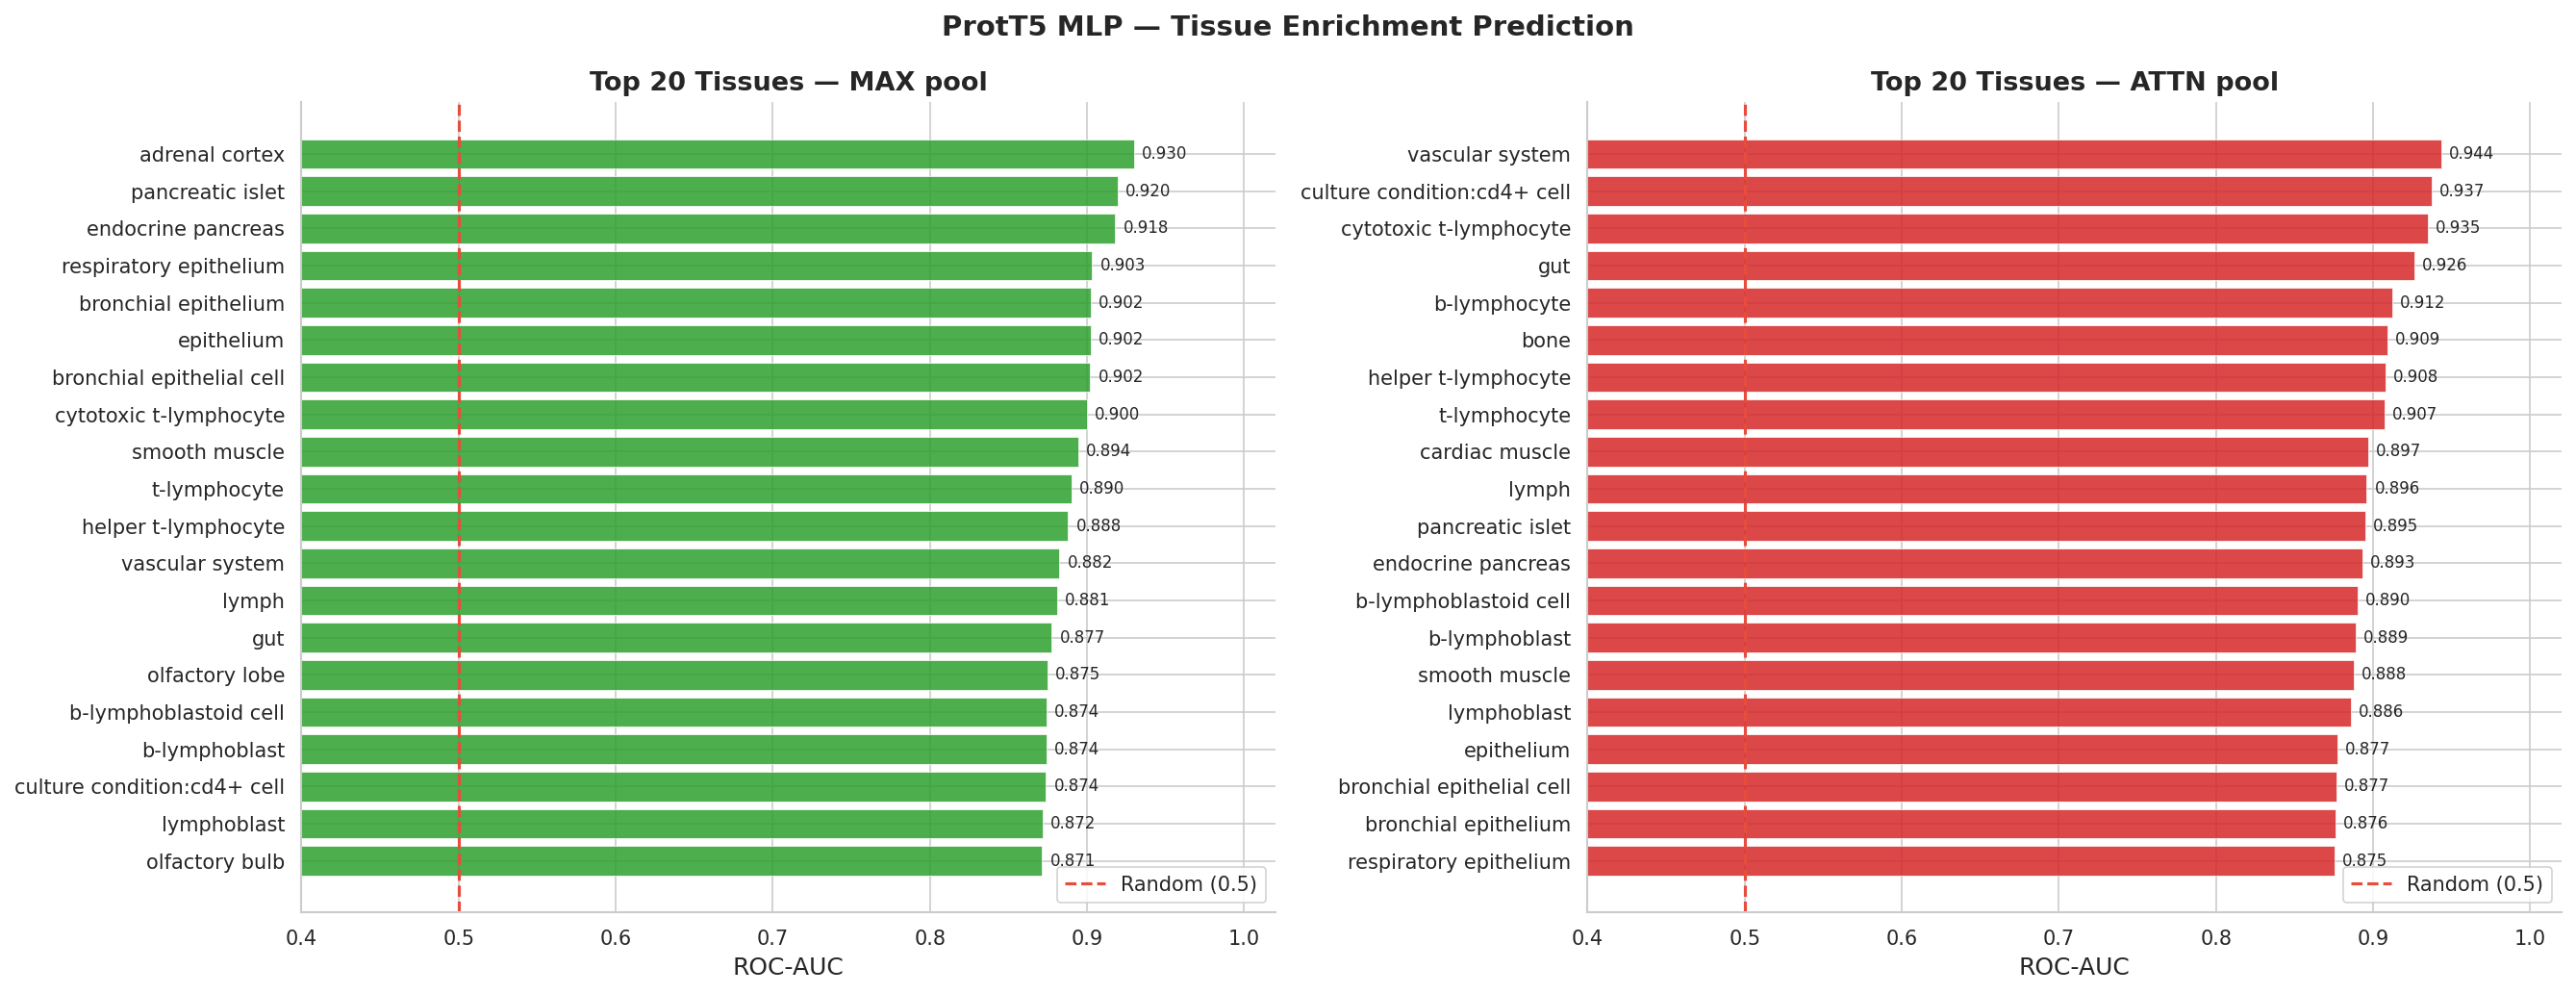

In [10]:
# ============================================================
# TOP / BOTTOM TISSUES BY ROC-AUC (both pools)
# ============================================================

metrics_by_pool = {}
for pool_name, res in eval_results.items():
    mdf = pd.DataFrame({
        "tissue":         res["tissue_names"],
        "roc_auc":        res["roc_aucs"],
        "pr_auc":         res["pr_aucs"],
        "pos_count_test": [
            int((res["Y_true"][:, TISSUE_COLS.index(t)] == 1).sum())
            for t in res["tissue_names"]
        ],
    }).sort_values("roc_auc", ascending=False)
    metrics_by_pool[pool_name] = mdf

    print(f"\n{'='*52}")
    print(f"  {pool_name.upper()} pool — Top 10 tissues by ROC-AUC")
    print(f"{'='*52}")
    display(mdf.head(10))

# ── Publication plot: top-20 horizontal bar chart ───────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors_bar = [PALETTE[2], PALETTE[3]]

for ax, (pool_name, mdf), color in zip(axes, metrics_by_pool.items(), colors_bar):
    top20 = mdf.head(20)
    bars = ax.barh(top20["tissue"][::-1], top20["roc_auc"][::-1],
                   color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.axvline(0.5, color="#e74c3c", ls="--", lw=1.5, label="Random (0.5)")
    for bar, val in zip(bars, top20["roc_auc"][::-1]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", ha="left", fontsize=8)
    ax.set_xlim(0.4, 1.02)
    ax.set_xlabel("ROC-AUC")
    ax.set_title(f"Top 20 Tissues — {pool_name.upper()} pool", fontweight="bold")
    ax.legend()

plt.suptitle("ProtT5 MLP — Tissue Enrichment Prediction",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "top20_tissues_roc_auc.png"), bbox_inches="tight")
plt.show()

In [11]:
# ============================================================
# SAVE ALL 235-TISSUE RESULTS
# ============================================================

import torch

for pool_name, res in eval_results.items():
    mdf = metrics_by_pool[pool_name]
    mdf.to_csv(os.path.join(OUT_DIR, f"prodt5_{pool_name}_per_tissue_metrics.csv"), index=False)

    pred_df = pd.DataFrame(res["Y_prob"], columns=TISSUE_COLS)
    pred_df.insert(0, "UniProt_ID", df_ml.iloc[idx_test]["UniProt_ID"].values)
    pred_df.insert(1, "GeneSym",    df_ml.iloc[idx_test]["GeneSym"].values)
    pred_df.to_csv(os.path.join(OUT_DIR, f"prodt5_{pool_name}_test_predictions.csv"), index=False)

    if pool_name == "max":
        true_df = pd.DataFrame(res["Y_true"], columns=TISSUE_COLS)
        true_df.insert(0, "UniProt_ID", df_ml.iloc[idx_test]["UniProt_ID"].values)
        true_df.insert(1, "GeneSym",    df_ml.iloc[idx_test]["GeneSym"].values)
        true_df.to_csv(os.path.join(OUT_DIR, "prodt5_test_true_labels.csv"), index=False)

    model_obj, _ = trained_models[pool_name]
    torch.save(model_obj.state_dict(), os.path.join(OUT_DIR, f"prodt5_{pool_name}_mlp_weights.pt"))
    print(f"[{pool_name}] Saved metrics, predictions, and model weights.")

summary_rows = []
for pool_name, res in eval_results.items():
    summary_rows.append({
        "pool":                pool_name,
        "model":               "ProtT5 + MLP",
        "embedding_dim":       emb_dim,
        "n_proteins_ml":       len(df_ml),
        "n_tissues":           len(TISSUE_COLS),
        "n_tissues_evaluated": len(res["roc_aucs"]),
        "train_size":          len(idx_train),
        "test_size":           len(idx_test),
        "macro_roc_auc":       float(res["roc_aucs"].mean()),
        "macro_pr_auc":        float(res["pr_aucs"].mean()),
        "epochs":              EPOCHS,
        "batch_size":          BATCH_SIZE,
        "lr":                  LR,
    })

summary_df = pd.DataFrame(summary_rows).set_index("pool")
summary_df.to_csv(os.path.join(OUT_DIR, "prodt5_run_summary.csv"))

print("\n=== Run Summary ===")
display(summary_df.T)

[max] Saved metrics, predictions, and model weights.
[attn] Saved metrics, predictions, and model weights.

=== Run Summary ===


pool,max,attn
model,ProtT5 + MLP,ProtT5 + MLP
embedding_dim,1024,1024
n_proteins_ml,13081,13081
n_tissues,235,235
n_tissues_evaluated,235,235
train_size,10464,10464
test_size,2617,2617
macro_roc_auc,0.768761,0.796813
macro_pr_auc,0.277133,0.338281
epochs,40,40


## Focused Multi-label Classifier — 5 Target Tissues

Found  : ['brain', 'testis', 'lung', 'liver', 'kidney']
Missing: []

Label distribution (# enriched / total):
  Brain               :  7193 / 13081  (55.0%)
  Testis              :  3697 / 13081  (28.3%)
  Lung                :  2398 / 13081  (18.3%)
  Liver               :  1601 / 13081  (12.2%)
  Kidney              :  1600 / 13081  (12.2%)

Proteins enriched in ≥2 labels: 4160 (31.8%)


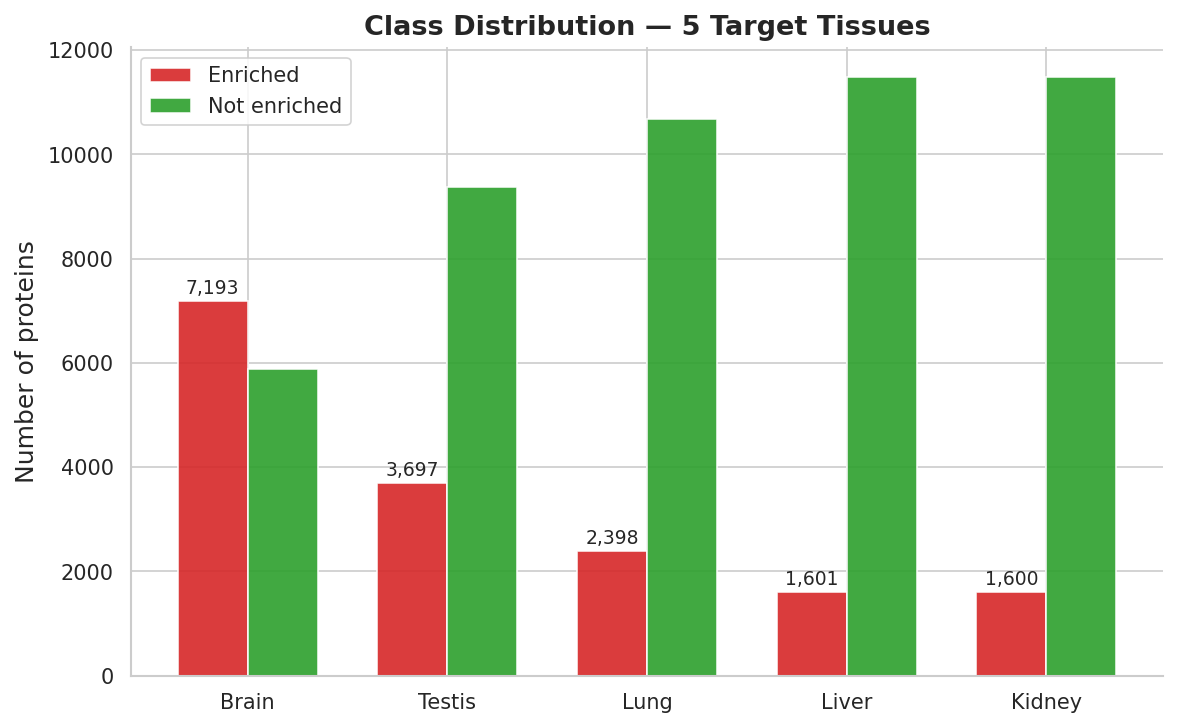

In [12]:
# ============================================================
# MULTI-LABEL CLASSIFICATION — 5 TARGET TISSUES
# ============================================================

TARGET_LABELS = ["brain", "testis", "lung", "liver", "kidney"]

found, missing = [], []
for t in TARGET_LABELS:
    if t in TISSUE_COLS:
        found.append(t)
    else:
        match = next((c for c in TISSUE_COLS if c.lower() == t.lower()), None)
        found.append(match) if match else missing.append(t)

print("Found  :", found)
print("Missing:", missing)
TARGET_LABELS = found
SHORT_NAMES   = [t.capitalize() for t in TARGET_LABELS]

Y5 = df_ml[TARGET_LABELS].apply(pd.to_numeric, errors="coerce").fillna(0).astype(np.float32).values

print("\nLabel distribution (# enriched / total):")
for i, (col, short) in enumerate(zip(TARGET_LABELS, SHORT_NAMES)):
    n_pos = int(Y5[:, i].sum())
    print(f"  {short:20s}: {n_pos:5d} / {len(Y5)}  ({100*n_pos/len(Y5):.1f}%)")

co = (Y5.sum(axis=1) > 1).sum()
print(f"\nProteins enriched in ≥2 labels: {co} ({100*co/len(Y5):.1f}%)")

# ── Publication plot: class distribution for 5 targets ──────
pos_counts_5 = Y5.sum(axis=0).astype(int)
neg_counts_5 = len(Y5) - pos_counts_5

x = np.arange(len(SHORT_NAMES))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, pos_counts_5, w, label="Enriched",     color=PALETTE[3], alpha=0.9)
b2 = ax.bar(x + w/2, neg_counts_5, w, label="Not enriched", color=PALETTE[2], alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES)
ax.set_ylabel("Number of proteins")
ax.set_title("Class Distribution — 5 Target Tissues", fontweight="bold")
ax.legend()
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "class_distribution_5targets.png"), bbox_inches="tight")
plt.show()

In [13]:
# ============================================================
# 3-WAY SPLIT: 70% train | 10% val | 20% test
# ============================================================

from sklearn.model_selection import train_test_split

X5    = X_attn   # attn pool
idx5  = np.arange(len(X5))

idx5_trval, idx5_test  = train_test_split(idx5,      test_size=0.20,  random_state=SEED)
idx5_train, idx5_val   = train_test_split(idx5_trval, test_size=0.125, random_state=SEED)

X5_train, Y5_train = X5[idx5_train], Y5[idx5_train]
X5_val,   Y5_val   = X5[idx5_val],   Y5[idx5_val]
X5_test,  Y5_test  = X5[idx5_test],  Y5[idx5_test]

print(f"Train : {len(idx5_train):,} ({100*len(idx5_train)/len(X5):.1f}%)")
print(f"Val   : {len(idx5_val):,}   ({100*len(idx5_val)/len(X5):.1f}%)")
print(f"Test  : {len(idx5_test):,}  ({100*len(idx5_test)/len(X5):.1f}%)")

pos5       = Y5_train.sum(axis=0)
neg5       = len(Y5_train) - pos5
pw5        = np.where(pos5 > 0, neg5 / pos5, 1.0).astype(np.float32)
pw5_tensor = torch.from_numpy(pw5).to(device)
print(f"\nPos weights: {dict(zip(SHORT_NAMES, pw5.round(1)))}")

Train : 9,156 (70.0%)
Val   : 1,308   (10.0%)
Test  : 2,617  (20.0%)

Pos weights: {'Brain': np.float32(0.8), 'Testis': np.float32(2.6), 'Lung': np.float32(4.5), 'Liver': np.float32(7.2), 'Kidney': np.float32(7.1)}


Epoch 025/300 | Train: 0.9892 | Val: 1.0185
Epoch 050/300 | Train: 0.9692 | Val: 1.0061
Epoch 075/300 | Train: 0.9531 | Val: 1.0044
Epoch 100/300 | Train: 0.9426 | Val: 1.0029
Early stopping @ epoch 121  (best val=1.0013 @ ep 91)

Restored best model from epoch 91  (val=1.0013)


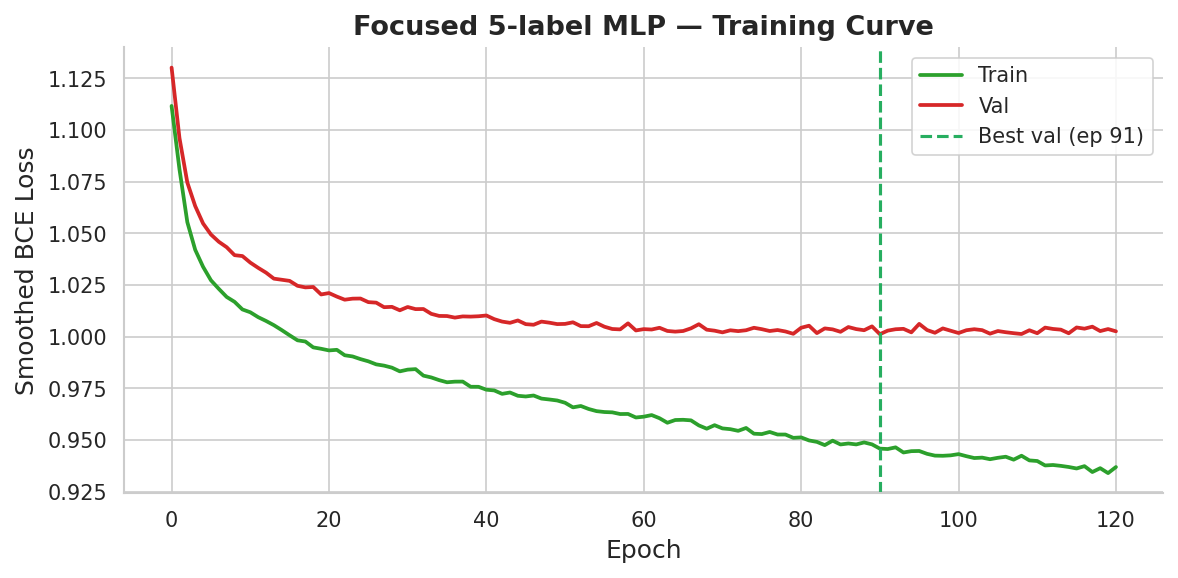

In [14]:
# ============================================================
# FOCUSED 5-LABEL MLP — label smoothing + AdamW regularisation
# ============================================================

import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


class FocusedMLP(nn.Module):
    def __init__(self, input_dim, num_labels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(128, num_labels),
        )
    def forward(self, x): return self.net(x)


EPOCHS5      = 300; BATCH_SIZE5 = 256; LR5 = 3e-4; PATIENCE5 = 30
LABEL_SMOOTH = 0.05

train5_ds     = TensorDataset(torch.from_numpy(X5_train), torch.from_numpy(Y5_train))
val5_ds       = TensorDataset(torch.from_numpy(X5_val),   torch.from_numpy(Y5_val))
train5_loader = DataLoader(train5_ds, batch_size=BATCH_SIZE5, shuffle=True)
val5_loader   = DataLoader(val5_ds,   batch_size=BATCH_SIZE5, shuffle=False)

pw5_capped = torch.clamp(pw5_tensor, max=20.0)

def smooth_bce(logits, targets, pw, s=0.05):
    t = targets * (1 - s) + (1 - targets) * s
    return nn.BCEWithLogitsLoss(pos_weight=pw)(logits, t)

model5     = FocusedMLP(X5_train.shape[1], 5).to(device)
optimizer5 = torch.optim.AdamW(model5.parameters(), lr=LR5, weight_decay=5e-2)
scheduler5 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer5, T_max=EPOCHS5, eta_min=1e-6)

train_losses5, val_losses5 = [], []
best_val5, best_epoch5, best_state5, patience_cnt = float("inf"), 0, None, 0

for epoch in range(1, EPOCHS5 + 1):
    model5.train(); tr_loss = 0.0
    for xb, yb in train5_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer5.zero_grad()
        loss = smooth_bce(model5(xb), yb, pw5_capped, LABEL_SMOOTH)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model5.parameters(), 1.0)
        optimizer5.step(); tr_loss += loss.item()

    model5.eval(); v_loss = 0.0
    with torch.no_grad():
        for xb, yb in val5_loader:
            v_loss += smooth_bce(model5(xb.to(device)), yb.to(device),
                                  pw5_capped, LABEL_SMOOTH).item()

    t_avg = tr_loss / len(train5_loader)
    v_avg = v_loss  / len(val5_loader)
    train_losses5.append(t_avg); val_losses5.append(v_avg)
    scheduler5.step()

    if v_avg < best_val5:
        best_val5, best_epoch5 = v_avg, epoch
        best_state5 = {k: v.cpu().clone() for k, v in model5.state_dict().items()}
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE5:
            print(f"Early stopping @ epoch {epoch}  (best val={best_val5:.4f} @ ep {best_epoch5})")
            break
    if epoch % 25 == 0:
        print(f"Epoch {epoch:03d}/{EPOCHS5} | Train: {t_avg:.4f} | Val: {v_avg:.4f}")

model5.load_state_dict({k: v.to(device) for k, v in best_state5.items()})
print(f"\nRestored best model from epoch {best_epoch5}  (val={best_val5:.4f})")

# ── Publication plot: training curve ────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses5, lw=1.8, color=PALETTE[2], label="Train")
ax.plot(val_losses5,   lw=1.8, color=PALETTE[3], label="Val")
ax.axvline(best_epoch5 - 1, ls="--", color="#27ae60", lw=1.5,
           label=f"Best val (ep {best_epoch5})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Smoothed BCE Loss")
ax.set_title("Focused 5-label MLP — Training Curve", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_training_loss.png"), bbox_inches="tight")
plt.show()

In [15]:
# ============================================================
# THRESHOLD TUNING ON VALIDATION SET
# ============================================================

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix,
)


def predict_proba5(model, loader):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(device))
            probs.append(torch.sigmoid(logits).cpu().numpy())
            labels.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(labels)


val_prob5, val_true5 = predict_proba5(model5, val5_loader)

thresholds_grid = np.arange(0.1, 0.9, 0.05)
best_thresh = []
for i in range(5):
    best_f1, best_t = -1, 0.5
    for t in thresholds_grid:
        pred = (val_prob5[:, i] >= t).astype(int)
        if pred.sum() == 0:
            continue
        f1 = f1_score(val_true5[:, i], pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresh.append(best_t)

print("Optimal thresholds (tuned on val):")
for name, t in zip(SHORT_NAMES, best_thresh):
    print(f"  {name:20s}: {t:.2f}")

val_pred5 = (val_prob5 >= np.array(best_thresh)).astype(int)
rows = []
for i, (full, short) in enumerate(zip(TARGET_LABELS, SHORT_NAMES)):
    rows.append(dict(
        label=short,
        roc_auc=roc_auc_score(val_true5[:, i], val_prob5[:, i]),
        pr_auc=average_precision_score(val_true5[:, i], val_prob5[:, i]),
        precision=precision_score(val_true5[:, i], val_pred5[:, i], zero_division=0),
        recall=recall_score(val_true5[:, i], val_pred5[:, i], zero_division=0),
        f1=f1_score(val_true5[:, i], val_pred5[:, i], zero_division=0),
        threshold=best_thresh[i],
    ))
val_stats = pd.DataFrame(rows).set_index("label")
print("\n=== Validation set metrics ===")
display(val_stats.round(4))

Optimal thresholds (tuned on val):
  Brain               : 0.35
  Testis              : 0.50
  Lung                : 0.65
  Liver               : 0.75
  Kidney              : 0.70

=== Validation set metrics ===


,roc_auc,pr_auc,precision,recall,f1,threshold
label,,,,,,
Brain,0.7580,0.7912,0.6487,0.8929,0.7514,0.35
Testis,0.7297,0.5581,0.4623,0.6769,0.5494,0.50
Lung,0.7524,0.4758,0.4745,0.4899,0.4821,0.65
Liver,0.8147,0.4112,0.4564,0.4595,0.4579,0.75
Kidney,0.7674,0.3899,0.3990,0.4793,0.4355,0.70


=== Test set (unseen) — per-label metrics ===


,roc_auc,pr_auc,precision,recall,f1
label,,,,,
Brain,0.7312,0.7731,0.6330,0.8629,0.7303
Testis,0.7116,0.5384,0.4279,0.6848,0.5267
Lung,0.7495,0.4976,0.4717,0.5061,0.4883
Liver,0.8325,0.5370,0.5224,0.5287,0.5255
Kidney,0.8036,0.4856,0.4014,0.5654,0.4695


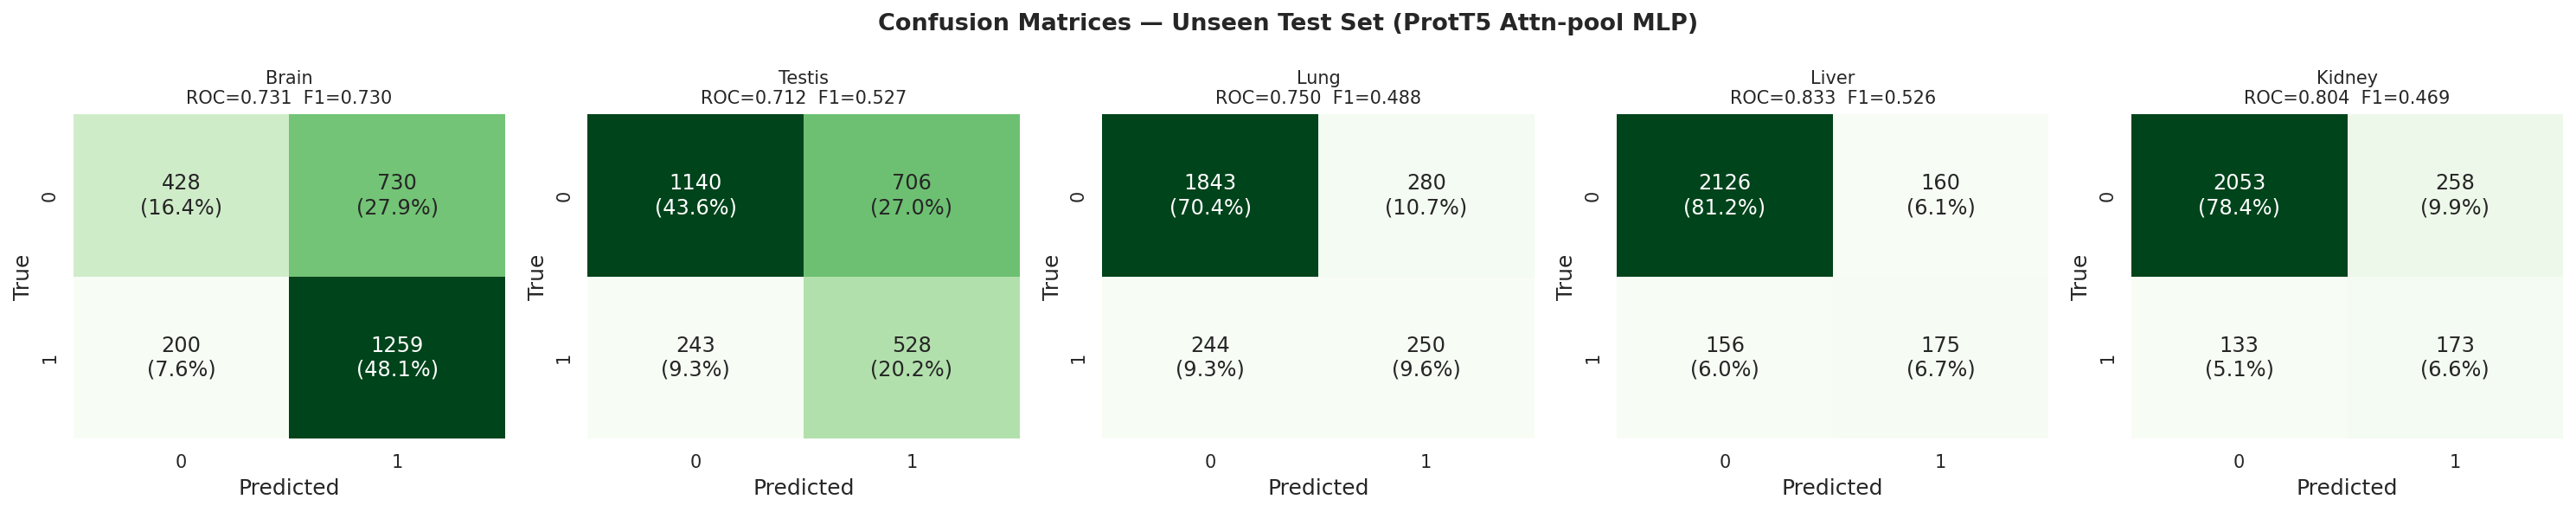

In [16]:
# ============================================================
# TEST SET — metrics + confusion matrices
# ============================================================

test5_ds     = TensorDataset(torch.from_numpy(X5_test), torch.from_numpy(Y5_test))
test5_loader = DataLoader(test5_ds, batch_size=BATCH_SIZE5, shuffle=False)

test_prob5, test_true5 = predict_proba5(model5, test5_loader)
test_pred5 = (test_prob5 >= np.array(best_thresh)).astype(int)

test_rows = []
for i, (full, short) in enumerate(zip(TARGET_LABELS, SHORT_NAMES)):
    roc = roc_auc_score(test_true5[:, i], test_prob5[:, i])
    ap  = average_precision_score(test_true5[:, i], test_prob5[:, i])
    p   = precision_score(test_true5[:, i], test_pred5[:, i], zero_division=0)
    r   = recall_score(test_true5[:, i],    test_pred5[:, i], zero_division=0)
    f1  = f1_score(test_true5[:, i],        test_pred5[:, i], zero_division=0)
    tn, fp, fn, tp = confusion_matrix(test_true5[:, i], test_pred5[:, i]).ravel()
    test_rows.append(dict(label=short, roc_auc=roc, pr_auc=ap,
                          precision=p, recall=r, f1=f1,
                          TP=tp, FP=fp, FN=fn, TN=tn,
                          threshold=best_thresh[i]))

test_stats = pd.DataFrame(test_rows).set_index("label")
print("=== Test set (unseen) — per-label metrics ===")
display(test_stats[["roc_auc", "pr_auc", "precision", "recall", "f1"]].round(4))

# ── Publication plot: confusion matrices ────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (ax, short) in enumerate(zip(axes, SHORT_NAMES)):
    cm    = confusion_matrix(test_true5[:, i], test_pred5[:, i])
    total = cm.sum()
    annot = np.array([[f"{v}\n({100*v/total:.1f}%)" for v in row] for row in cm])
    sns.heatmap(cm, annot=annot, fmt="", ax=ax, cmap="Greens", cbar=False,
                xticklabels=["0", "1"], yticklabels=["0", "1"])
    ax.set_title(
        f"{short}\nROC={test_stats.loc[short,'roc_auc']:.3f}  F1={test_stats.loc[short,'f1']:.3f}",
        fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.suptitle("Confusion Matrices — Unseen Test Set (ProtT5 Attn-pool MLP)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_confusion_matrices.png"), bbox_inches="tight")
plt.show()

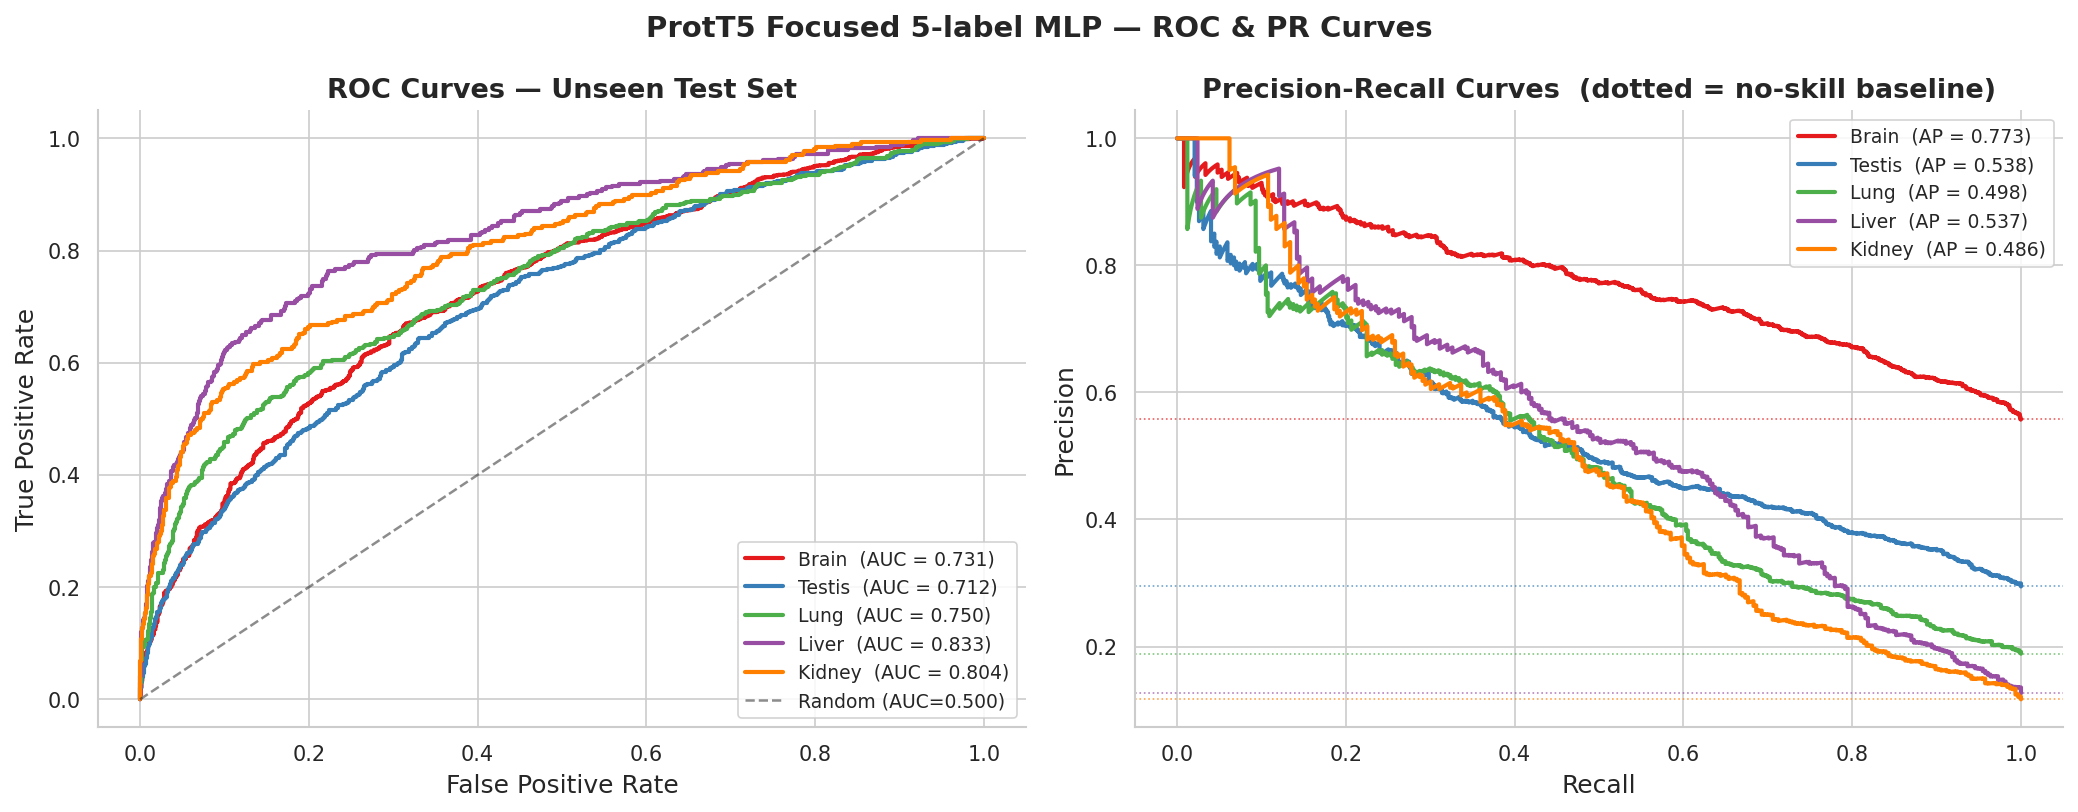

In [17]:
# ============================================================
# ROC & PR CURVES — test set  (publication-grade)
# ============================================================

from sklearn.metrics import roc_curve, precision_recall_curve

TISSUE_COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for i, (short, color) in enumerate(zip(SHORT_NAMES, TISSUE_COLORS)):
    fpr,  tpr,  _ = roc_curve(test_true5[:, i], test_prob5[:, i])
    prec, rec,  _ = precision_recall_curve(test_true5[:, i], test_prob5[:, i])
    prev           = test_true5[:, i].mean()

    roc_val = test_stats.loc[short, "roc_auc"]
    ap_val  = test_stats.loc[short, "pr_auc"]

    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{short}  (AUC = {roc_val:.3f})")
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f"{short}  (AP = {ap_val:.3f})")
    axes[1].axhline(prev, color=color, lw=0.8, ls=":", alpha=0.7)

axes[0].plot([0, 1], [0, 1], "k--", lw=1.2, alpha=0.5, label="Random (AUC=0.500)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Unseen Test Set", fontweight="bold")
axes[0].legend(fontsize=9, loc="lower right")

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves  (dotted = no-skill baseline)",
                  fontweight="bold")
axes[1].legend(fontsize=9, loc="upper right")

plt.suptitle("ProtT5 Focused 5-label MLP — ROC & PR Curves",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_roc_pr_curves.png"), bbox_inches="tight")
plt.show()

In [18]:
# ============================================================
# SAVE FOCUSED MODEL RESULTS
# ============================================================

from sklearn.metrics import hamming_loss

test_stats.to_csv(os.path.join(OUT_DIR, "focused5_test_metrics.csv"))

pred_out = pd.DataFrame(test_prob5, columns=[f"prob_{s}" for s in SHORT_NAMES])
for i, s in enumerate(SHORT_NAMES):
    pred_out[f"pred_{s}"] = test_pred5[:, i]
    pred_out[f"true_{s}"] = test_true5[:, i].astype(int)
pred_out.insert(0, "UniProt_ID", df_ml.iloc[idx5_test]["UniProt_ID"].values)
pred_out.insert(1, "GeneSym",    df_ml.iloc[idx5_test]["GeneSym"].values)
pred_out.to_csv(os.path.join(OUT_DIR, "focused5_test_predictions.csv"), index=False)

torch.save(model5.state_dict(), os.path.join(OUT_DIR, "focused5_mlp_weights.pt"))
print("Saved: test_metrics, test_predictions, model_weights")

print(f"\nHamming loss (test) : {hamming_loss(test_true5, test_pred5):.4f}")
print(f"Macro F1    (test)  : {f1_score(test_true5, test_pred5, average='macro',   zero_division=0):.4f}")
print(f"Micro F1    (test)  : {f1_score(test_true5, test_pred5, average='micro',   zero_division=0):.4f}")
print(f"Sample F1   (test)  : {f1_score(test_true5, test_pred5, average='samples', zero_division=0):.4f}")
print(f"\nMacro ROC-AUC       : {test_stats['roc_auc'].mean():.4f}")
print(f"Macro PR-AUC        : {test_stats['pr_auc'].mean():.4f}")

Saved: test_metrics, test_predictions, model_weights

Hamming loss (test) : 0.2377
Macro F1    (test)  : 0.5480
Micro F1    (test)  : 0.6053
Sample F1   (test)  : 0.4027

Macro ROC-AUC       : 0.7657
Macro PR-AUC        : 0.5664


=== Test Metrics vs Random Baseline ===


,prevalence,ROC_model,ROC_random,ROC_gain,PRAUC_model,PRAUC_random,PRAUC_gain,F1_model,F1_random,F1_gain
label,,,,,,,,,,
Brain,0.5575,0.7312,0.5,0.2312,0.7731,0.5575,0.2156,0.7303,0.7159,0.0144
Testis,0.2946,0.7116,0.5,0.2116,0.5384,0.2946,0.2438,0.5267,0.4551,0.0715
Lung,0.1888,0.7495,0.5,0.2495,0.4976,0.1888,0.3089,0.4883,0.3176,0.1707
Liver,0.1265,0.8325,0.5,0.3325,0.5370,0.1265,0.4105,0.5255,0.2246,0.3010
Kidney,0.1169,0.8036,0.5,0.3036,0.4856,0.1169,0.3686,0.4695,0.2094,0.2601


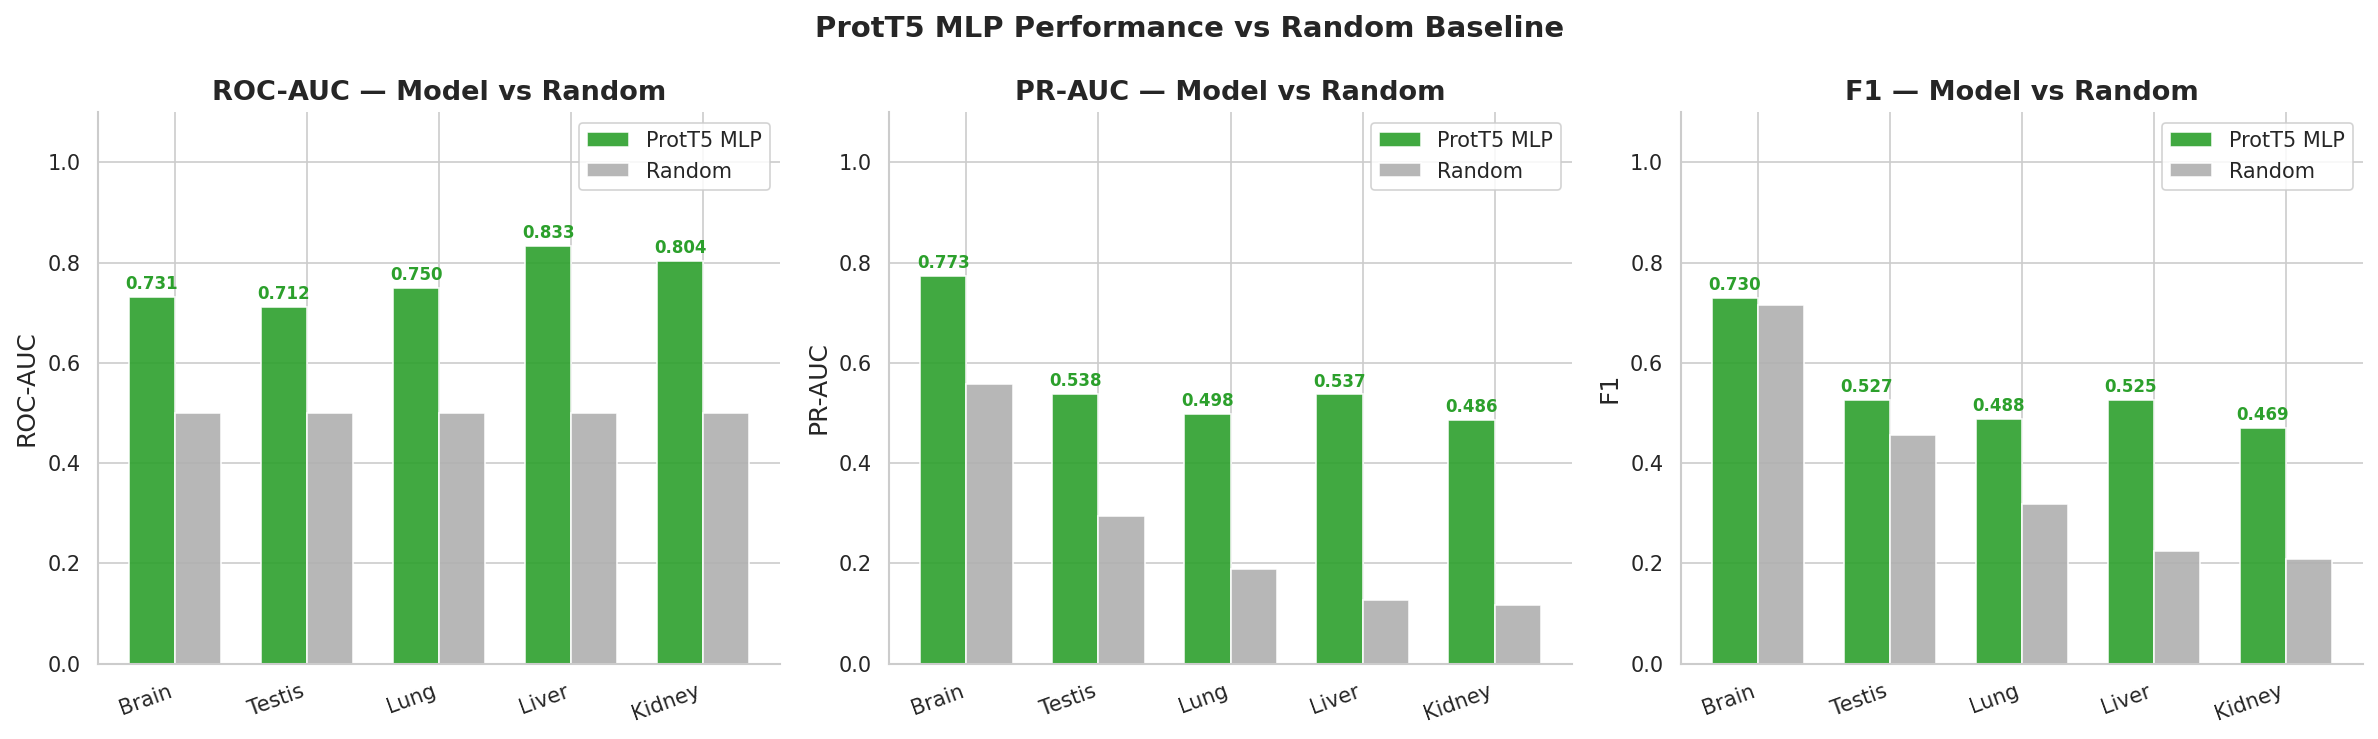

In [19]:
# ============================================================
# METRICS VS RANDOM BASELINE — publication table + bar chart
# ============================================================

baseline_rows = []
for i, (full, short) in enumerate(zip(TARGET_LABELS, SHORT_NAMES)):
    prev     = float(test_true5[:, i].mean())
    rand_f1  = 2 * prev / (1 + prev) if prev > 0 else 0.0
    baseline_rows.append(dict(
        label        = short,
        prevalence   = round(prev, 4),
        ROC_model    = round(test_stats.loc[short, "roc_auc"], 4),
        ROC_random   = 0.5,
        ROC_gain     = round(test_stats.loc[short, "roc_auc"] - 0.5, 4),
        PRAUC_model  = round(test_stats.loc[short, "pr_auc"],  4),
        PRAUC_random = round(prev, 4),
        PRAUC_gain   = round(test_stats.loc[short, "pr_auc"] - prev, 4),
        F1_model     = round(test_stats.loc[short, "f1"], 4),
        F1_random    = round(rand_f1, 4),
        F1_gain      = round(test_stats.loc[short, "f1"] - rand_f1, 4),
    ))

comp_df = pd.DataFrame(baseline_rows).set_index("label")
print("=== Test Metrics vs Random Baseline ===")
display(comp_df)
comp_df.to_csv(os.path.join(OUT_DIR, "focused5_baseline_comparison.csv"))

# ── Publication plot: model vs baseline grouped bars ────────
metrics_to_plot = [("ROC-AUC", "ROC_model", "ROC_random"),
                   ("PR-AUC",  "PRAUC_model", "PRAUC_random"),
                   ("F1",      "F1_model",   "F1_random")]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(SHORT_NAMES))
w = 0.35

for ax, (metric_name, model_col, rand_col) in zip(axes, metrics_to_plot):
    m_vals = comp_df[model_col].values
    r_vals = comp_df[rand_col].values
    b1 = ax.bar(x - w/2, m_vals, w, label="ProtT5 MLP", color=PALETTE[2], alpha=0.9)
    b2 = ax.bar(x + w/2, r_vals, w, label="Random",     color="#b0b0b0",   alpha=0.9)
    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8,
                fontweight="bold", color=PALETTE[2])
    ax.set_xticks(x); ax.set_xticklabels(SHORT_NAMES, rotation=20, ha="right")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} — Model vs Random", fontweight="bold")
    ax.legend()

plt.suptitle("ProtT5 MLP Performance vs Random Baseline",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_vs_baseline.png"), bbox_inches="tight")
plt.show()

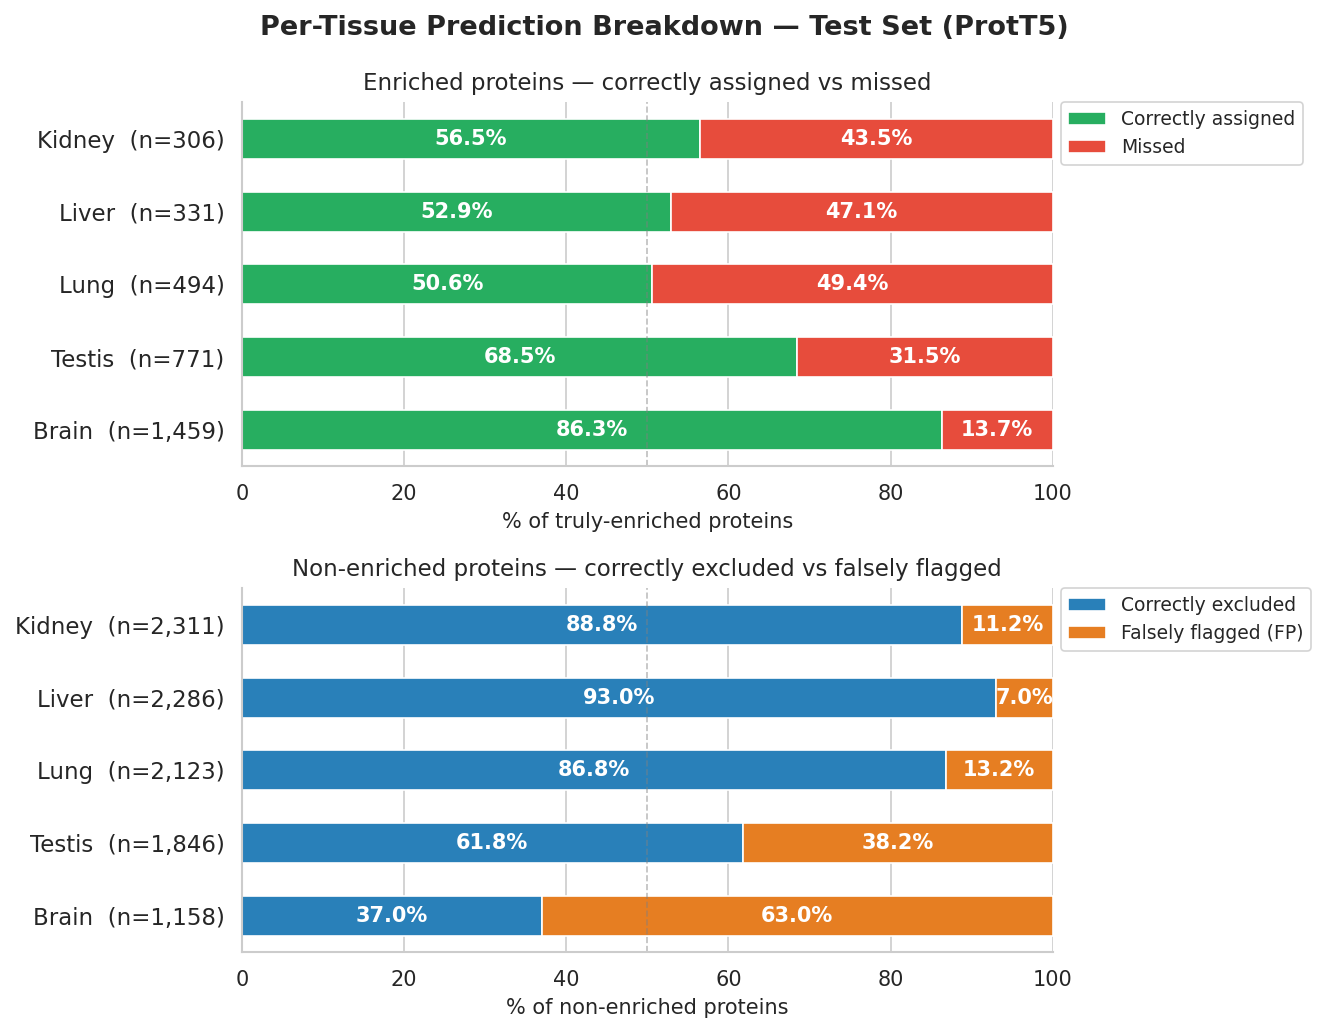

In [20]:
# ============================================================
# PER-TISSUE RECALL BREAKDOWN  (publication-grade)
# ============================================================

recalls, miss_rates, specs, fpr_rates, n_pos_list, n_neg_list = [], [], [], [], [], []
for i, short in enumerate(SHORT_NAMES):
    tp = test_stats.loc[short, "TP"]
    fn = test_stats.loc[short, "FN"]
    tn = test_stats.loc[short, "TN"]
    fp = test_stats.loc[short, "FP"]
    n_pos = tp + fn;  n_neg = tn + fp
    recalls.append(tp / n_pos * 100)
    miss_rates.append(fn / n_pos * 100)
    specs.append(tn / n_neg * 100)
    fpr_rates.append(fp / n_neg * 100)
    n_pos_list.append(n_pos)
    n_neg_list.append(n_neg)

y = np.arange(len(SHORT_NAMES))
h = 0.55

colors_pos = ["#27ae60", "#e74c3c"]
colors_neg = ["#2980b9", "#e67e22"]

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=False)

axes[0].barh(y, recalls,    height=h, color=colors_pos[0], label="Correctly assigned")
axes[0].barh(y, miss_rates, height=h, left=recalls,        color=colors_pos[1], label="Missed")
for i, (r, m) in enumerate(zip(recalls, miss_rates)):
    axes[0].text(r/2,   i, f"{r:.1f}%", ha="center", va="center",
                 fontsize=10, fontweight="bold", color="white")
    axes[0].text(r+m/2, i, f"{m:.1f}%", ha="center", va="center",
                 fontsize=10, fontweight="bold", color="white")
axes[0].set_yticks(y)
axes[0].set_yticklabels([f"{s}  (n={n:,})" for s, n in zip(SHORT_NAMES, n_pos_list)], fontsize=11)
axes[0].set_xlim(0, 100)
axes[0].set_xlabel("% of truly-enriched proteins", fontsize=10)
axes[0].set_title("Enriched proteins — correctly assigned vs missed", fontsize=11)
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=9)
axes[0].axvline(50, color="gray", ls="--", lw=0.8, alpha=0.5)

axes[1].barh(y, specs,     height=h, color=colors_neg[0], label="Correctly excluded")
axes[1].barh(y, fpr_rates, height=h, left=specs,          color=colors_neg[1], label="Falsely flagged (FP)")
for i, (s, f) in enumerate(zip(specs, fpr_rates)):
    axes[1].text(s/2,   i, f"{s:.1f}%", ha="center", va="center",
                 fontsize=10, fontweight="bold", color="white")
    axes[1].text(s+f/2, i, f"{f:.1f}%", ha="center", va="center",
                 fontsize=10, fontweight="bold", color="white")
axes[1].set_yticks(y)
axes[1].set_yticklabels([f"{s}  (n={n:,})" for s, n in zip(SHORT_NAMES, n_neg_list)], fontsize=11)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("% of non-enriched proteins", fontsize=10)
axes[1].set_title("Non-enriched proteins — correctly excluded vs falsely flagged", fontsize=11)
axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=9)
axes[1].axvline(50, color="gray", ls="--", lw=0.8, alpha=0.5)

plt.suptitle("Per-Tissue Prediction Breakdown — Test Set (ProtT5)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_recall_breakdown.png"), bbox_inches="tight")
plt.show()

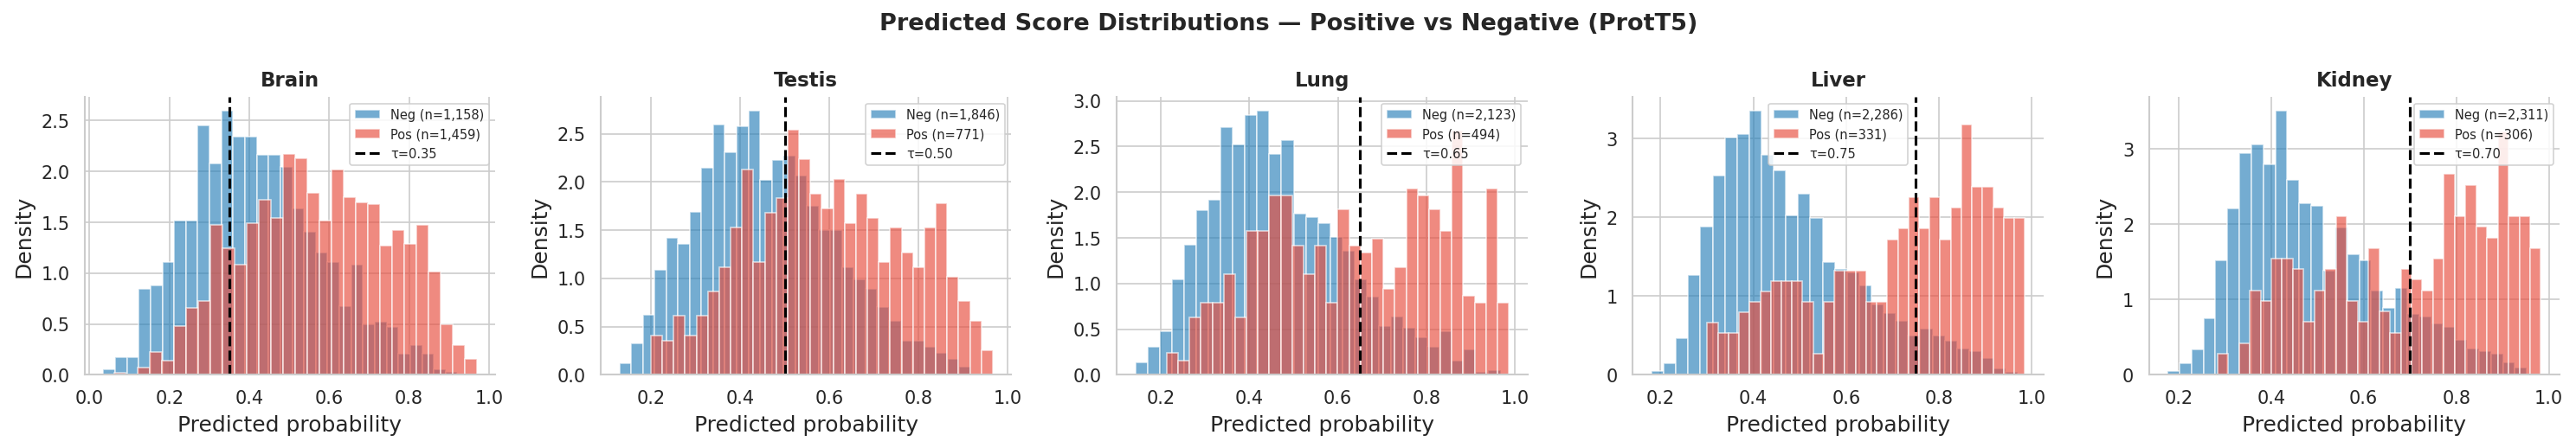

In [21]:
# ============================================================
# SCORE DISTRIBUTIONS — positive vs negative proteins
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))

for i, (ax, short, color) in enumerate(zip(axes, SHORT_NAMES, TISSUE_COLORS)):
    pos_mask = test_true5[:, i].astype(bool)
    neg_mask = ~pos_mask

    ax.hist(test_prob5[neg_mask, i], bins=30, alpha=0.65, color="#2980b9",
            label=f"Neg (n={neg_mask.sum():,})", density=True)
    ax.hist(test_prob5[pos_mask, i], bins=30, alpha=0.65, color="#e74c3c",
            label=f"Pos (n={pos_mask.sum():,})", density=True)
    ax.axvline(best_thresh[i], color="black", ls="--", lw=1.5,
               label=f"τ={best_thresh[i]:.2f}")
    ax.set_title(short, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

plt.suptitle("Predicted Score Distributions — Positive vs Negative (ProtT5)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_score_distributions.png"), bbox_inches="tight")
plt.show()

/nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/protT5_env/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running PCA...
  Variance explained: PC1=9.7%  PC2=6.2%
Running UMAP...


/nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/protT5_env/lib64/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  UMAP done.


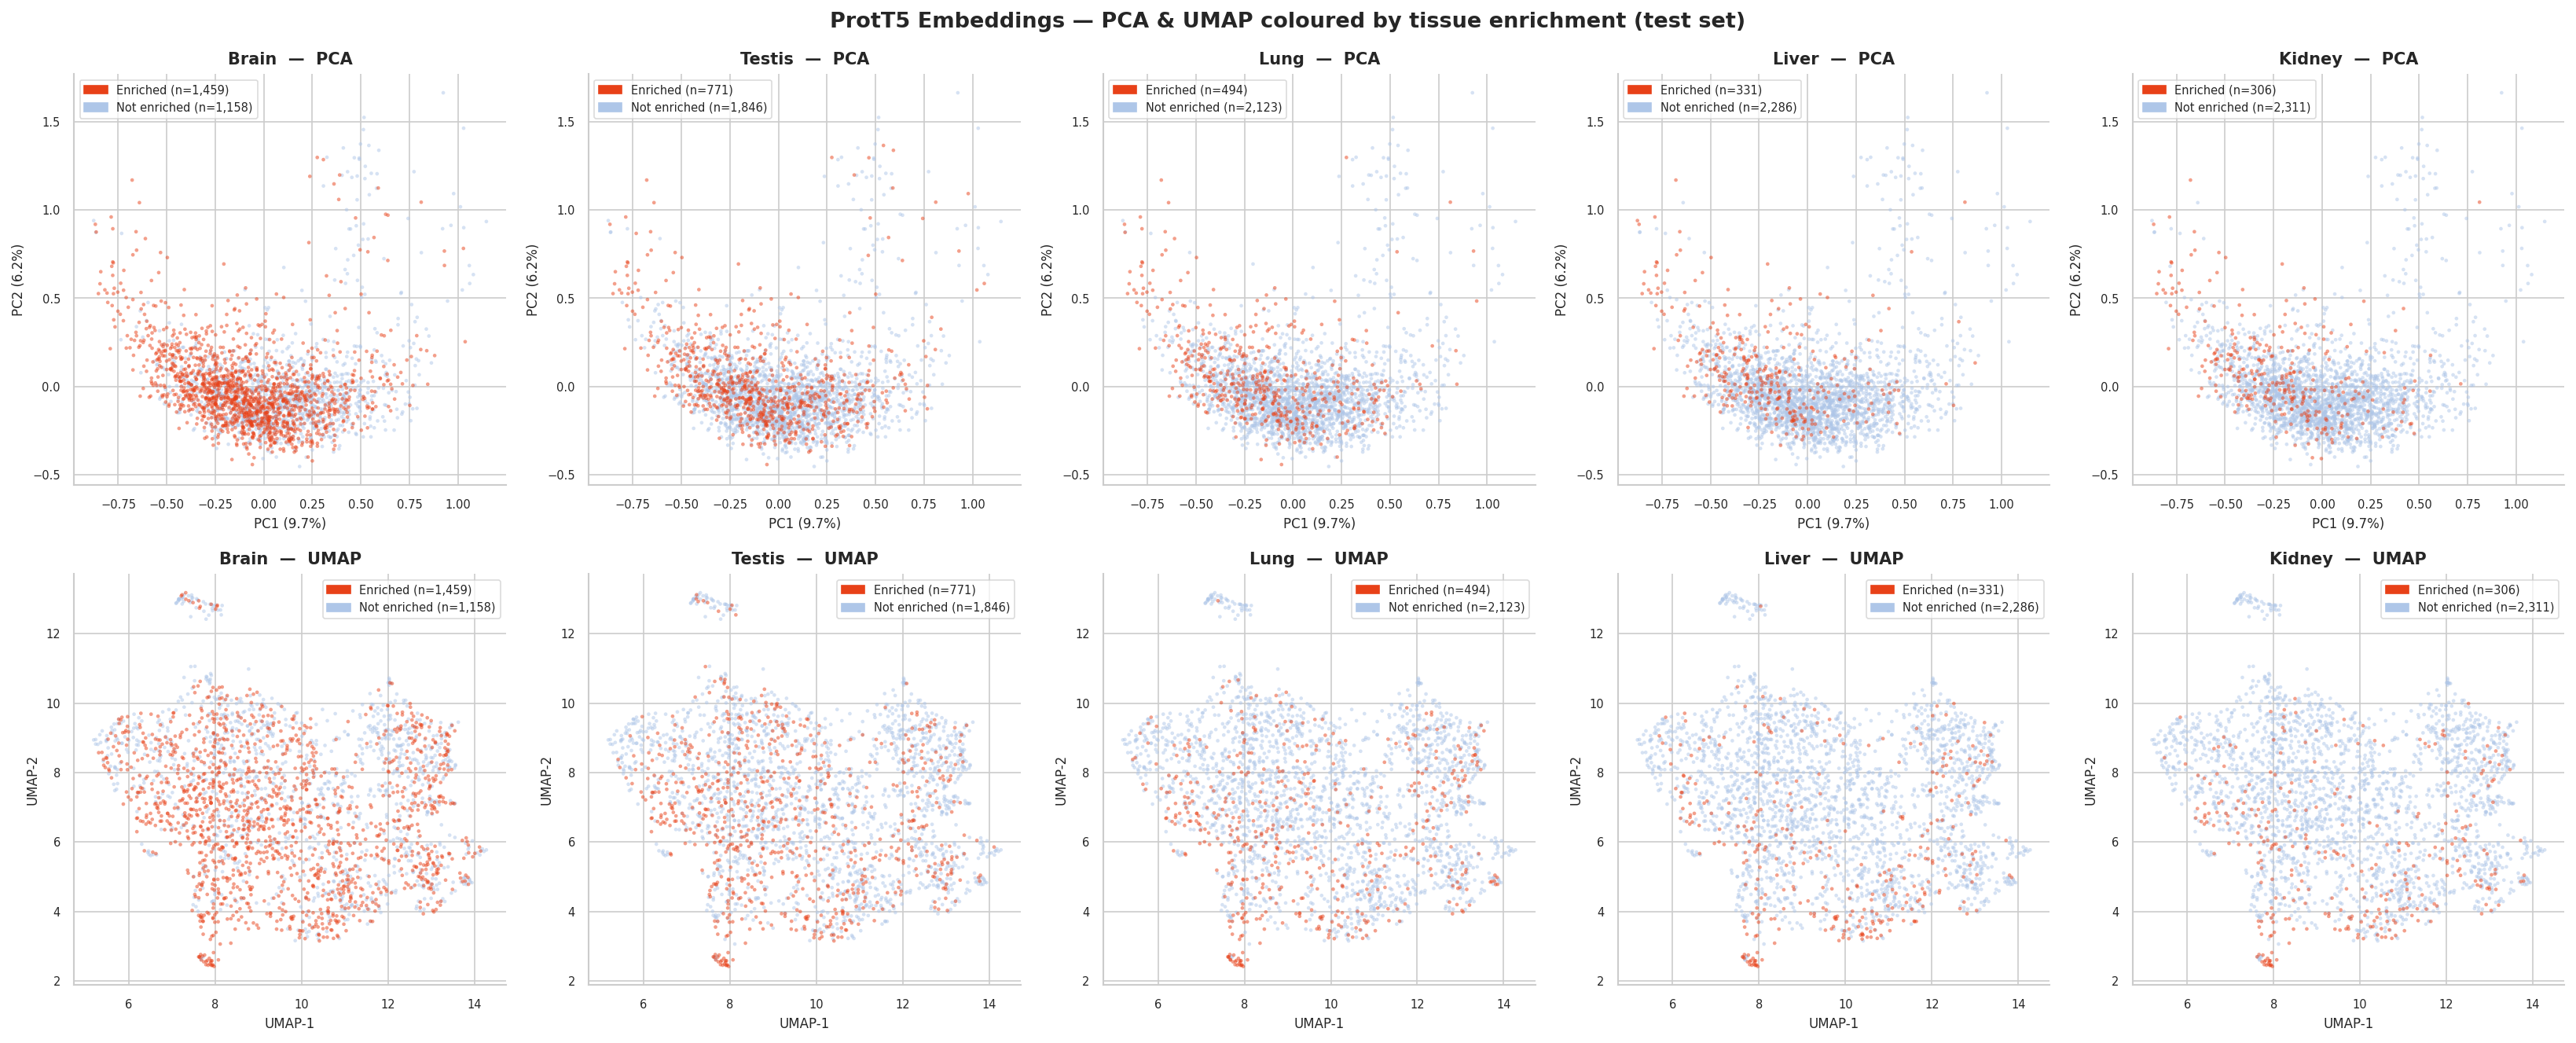

Saved → prodt5_results/focused5_pca_umap.png


In [22]:
# ============================================================
# PCA & UMAP — test-set embeddings coloured by tissue
# ============================================================

from sklearn.decomposition import PCA
from matplotlib.patches import Patch

try:
    import umap as umap_module
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "umap-learn"], check=True)
    import umap as umap_module

X_embed = X5_test
Y_embed = test_true5

print("Running PCA...")
pca    = PCA(n_components=2, random_state=SEED)
X_pca  = pca.fit_transform(X_embed)
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
print(f"  Variance explained: PC1={var_pc1:.1f}%  PC2={var_pc2:.1f}%")

print("Running UMAP...")
reducer = umap_module.UMAP(n_components=2, n_neighbors=30, min_dist=0.3,
                            random_state=SEED, verbose=False)
X_umap  = reducer.fit_transform(X_embed)
print("  UMAP done.")

COL_POS = "#e84118"
COL_NEG = "#aec6e8"

fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for col, short in enumerate(SHORT_NAMES):
    lbl    = Y_embed[:, col].astype(int)
    colors = np.where(lbl == 1, COL_POS, COL_NEG)
    order  = np.argsort(lbl)
    n_pos  = int(lbl.sum())
    n_neg  = len(lbl) - n_pos

    legend_handles = [
        Patch(color=COL_POS, label=f"Enriched (n={n_pos:,})"),
        Patch(color=COL_NEG, label=f"Not enriched (n={n_neg:,})"),
    ]

    for row_idx, (emb, xlabel, ylabel) in enumerate([
        (X_pca,  f"PC1 ({var_pc1:.1f}%)", f"PC2 ({var_pc2:.1f}%)"),
        (X_umap, "UMAP-1",               "UMAP-2"),
    ]):
        ax = axes[row_idx, col]
        ax.scatter(emb[order, 0], emb[order, 1],
                   c=colors[order], s=5, alpha=0.5, linewidths=0, rasterized=True)
        ax.set_title(f"{short}  —  {'PCA' if row_idx==0 else 'UMAP'}",
                     fontsize=10, fontweight="bold")
        ax.set_xlabel(xlabel, fontsize=8); ax.set_ylabel(ylabel, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.legend(handles=legend_handles, fontsize=7, loc="best", framealpha=0.7)

plt.suptitle("ProtT5 Embeddings — PCA & UMAP coloured by tissue enrichment (test set)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_pca_umap.png"), bbox_inches="tight")
plt.show()
print(f"Saved → {os.path.join(OUT_DIR, 'focused5_pca_umap.png')}")

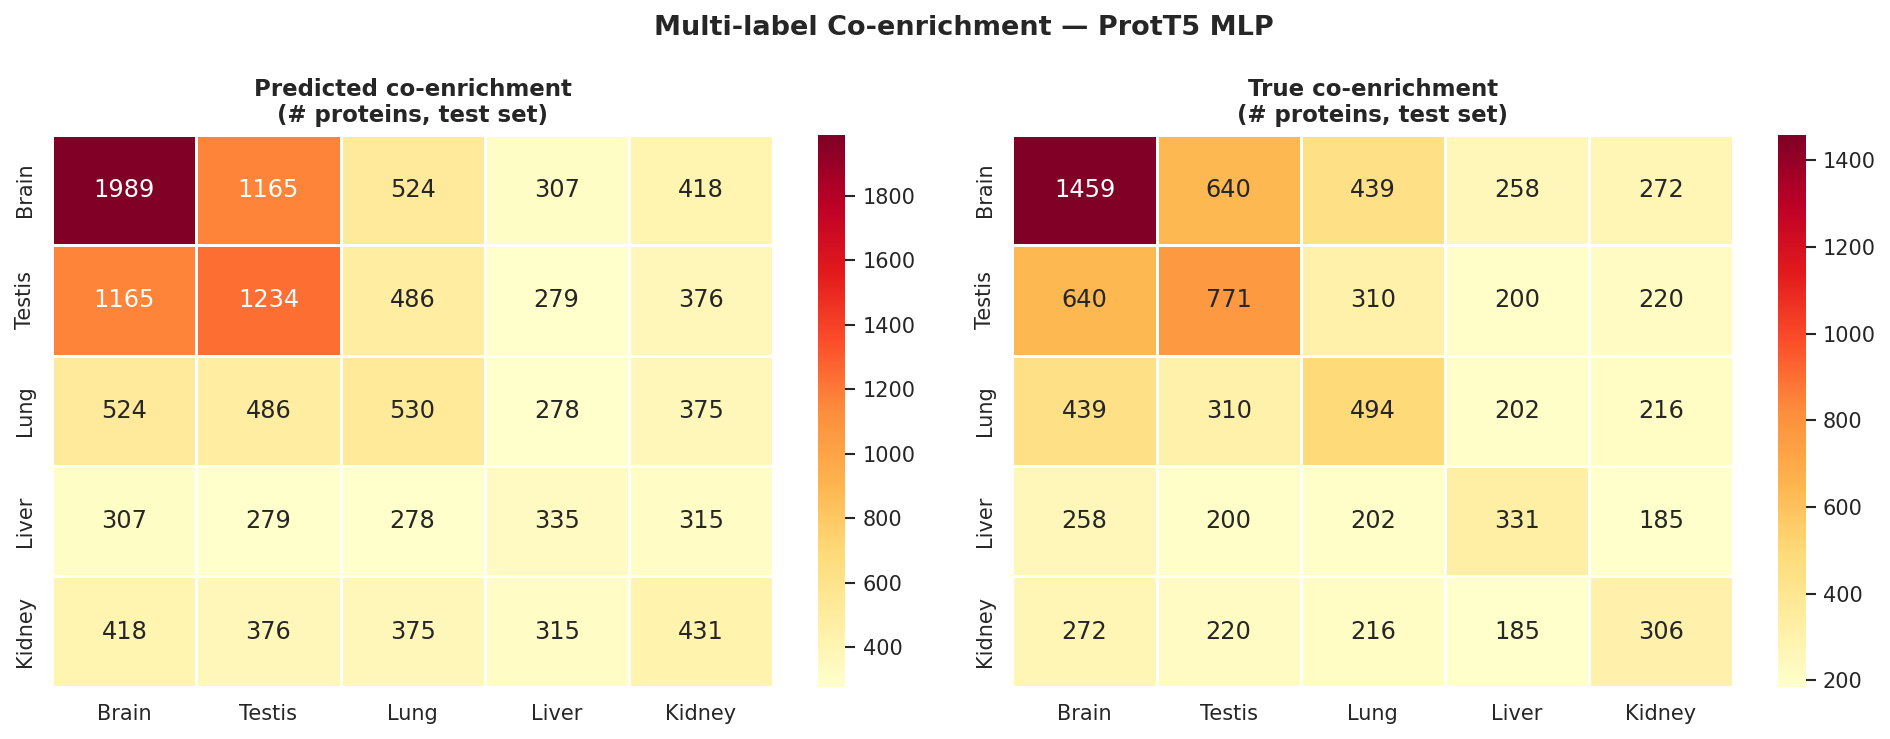

In [23]:
# ============================================================
# CO-ENRICHMENT HEATMAPS — predicted vs true (publication)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, matrix, title in [
    (axes[0], (test_pred5.T @ test_pred5), "Predicted co-enrichment"),
    (axes[1], (test_true5.T @ test_true5).astype(int), "True co-enrichment"),
]:
    df_co = pd.DataFrame(matrix, index=SHORT_NAMES, columns=SHORT_NAMES)
    sns.heatmap(df_co, annot=True, fmt="d", cmap="YlOrRd", ax=ax, cbar=True,
                linewidths=0.5, linecolor="white")
    ax.set_title(f"{title}\n(# proteins, test set)", fontsize=11, fontweight="bold")

plt.suptitle("Multi-label Co-enrichment — ProtT5 MLP",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_co_enrichment.png"), bbox_inches="tight")
plt.show()

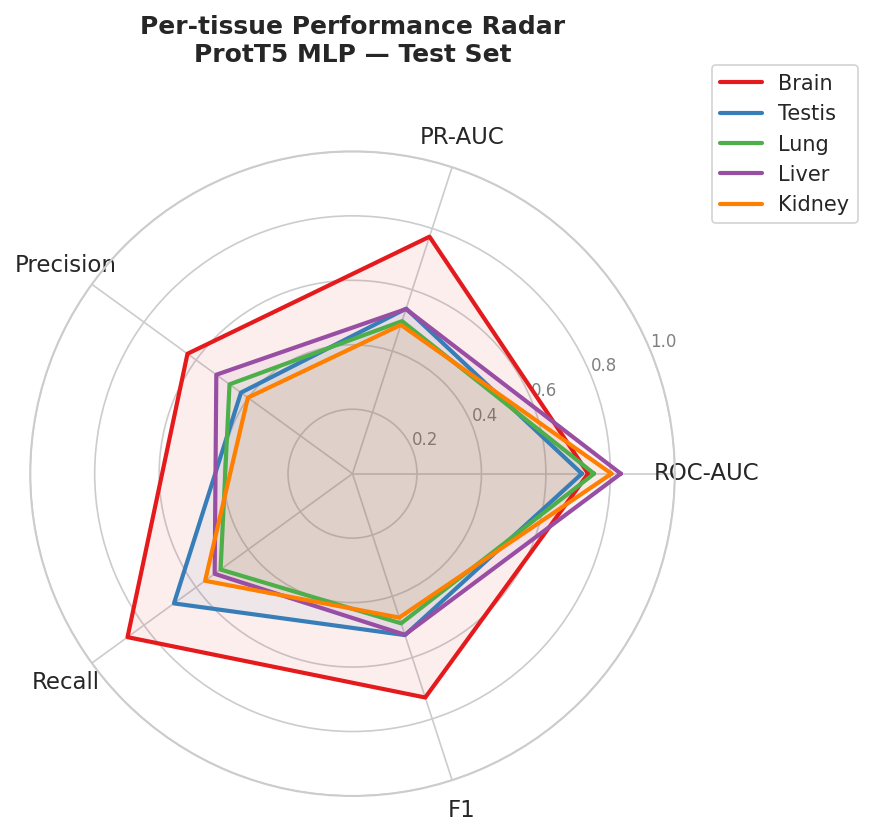

In [24]:
# ============================================================
# SUMMARY RADAR / SPIDER CHART — per-tissue metrics
# ============================================================

metrics_radar = ["roc_auc", "pr_auc", "precision", "recall", "f1"]
labels_radar  = ["ROC-AUC", "PR-AUC", "Precision", "Recall", "F1"]
N = len(metrics_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for short, color in zip(SHORT_NAMES, TISSUE_COLORS):
    values = [test_stats.loc[short, m] for m in metrics_radar]
    values += values[:1]
    ax.plot(angles, values, color=color, lw=2, label=short)
    ax.fill(angles, values, color=color, alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8, color="gray")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15), fontsize=10)
ax.set_title("Per-tissue Performance Radar\nProtT5 MLP — Test Set",
             y=1.12, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "focused5_radar_chart.png"), bbox_inches="tight")
plt.show()

In [25]:
# ============================================================
# FINAL SUMMARY TABLE
# ============================================================

print("=" * 60)
print("  ProtT5 Tissue Enrichment MLP — Final Summary")
print("=" * 60)
print(f"  Embedding model      : ProtT5 (1024-dim)")
print(f"  Proteins (after dedup): {len(df_ml):,}")
print(f"  Tissues (235-task)   : macro ROC-AUC = "
      f"{eval_results['attn']['roc_aucs'].mean():.4f}  "
      f"macro PR-AUC = {eval_results['attn']['pr_aucs'].mean():.4f}")
print(f"  5-task (test set)    : macro ROC-AUC = "
      f"{test_stats['roc_auc'].mean():.4f}  "
      f"macro PR-AUC = {test_stats['pr_auc'].mean():.4f}")
print("")
print("  Per-label test metrics:")
display(test_stats[["roc_auc", "pr_auc", "precision", "recall", "f1"]].round(4))

saved_files = [
    "label_distribution.png",
    "training_loss_235.png",
    "per_tissue_auc_distributions.png",
    "top20_tissues_roc_auc.png",
    "class_distribution_5targets.png",
    "focused5_training_loss.png",
    "focused5_confusion_matrices.png",
    "focused5_roc_pr_curves.png",
    "focused5_vs_baseline.png",
    "focused5_recall_breakdown.png",
    "focused5_score_distributions.png",
    "focused5_pca_umap.png",
    "focused5_co_enrichment.png",
    "focused5_radar_chart.png",
]
print(f"\n  All outputs saved to: {os.path.abspath(OUT_DIR)}/")
for f in saved_files:
    exists = os.path.exists(os.path.join(OUT_DIR, f))
    print(f"    {'✓' if exists else '✗'}  {f}")

  ProtT5 Tissue Enrichment MLP — Final Summary
  Embedding model      : ProtT5 (1024-dim)
  Proteins (after dedup): 13,081
  Tissues (235-task)   : macro ROC-AUC = 0.7968  macro PR-AUC = 0.3383
  5-task (test set)    : macro ROC-AUC = 0.7657  macro PR-AUC = 0.5664

  Per-label test metrics:


,roc_auc,pr_auc,precision,recall,f1
label,,,,,
Brain,0.7312,0.7731,0.6330,0.8629,0.7303
Testis,0.7116,0.5384,0.4279,0.6848,0.5267
Lung,0.7495,0.4976,0.4717,0.5061,0.4883
Liver,0.8325,0.5370,0.5224,0.5287,0.5255
Kidney,0.8036,0.4856,0.4014,0.5654,0.4695



  All outputs saved to: /home/saishyam/Protein_dynamics/Dynamic_properties/Protein_Cell_tissue_confidence/prodt5_results/
    ✓  label_distribution.png
    ✓  training_loss_235.png
    ✓  per_tissue_auc_distributions.png
    ✓  top20_tissues_roc_auc.png
    ✓  class_distribution_5targets.png
    ✓  focused5_training_loss.png
    ✓  focused5_confusion_matrices.png
    ✓  focused5_roc_pr_curves.png
    ✓  focused5_vs_baseline.png
    ✓  focused5_recall_breakdown.png
    ✓  focused5_score_distributions.png
    ✓  focused5_pca_umap.png
    ✓  focused5_co_enrichment.png
    ✓  focused5_radar_chart.png
